# Simulation results analysis

Reads `Input_Results_redo.csv` and produces:

1. Corrected `MPM` values (subtract the mean).
2. Per Hs: 6 subplots (3 DOFs × {MPM, Std}) averaged over wave directions, one line per damping case.
3. Per Hs: 6 subplots of MPM and Std per direction (low damping only).
4. Per Hs: 6 subplots of the **percentage difference vs. the `low` case** (3 lines per subplot).
5. Per DOF: the most extreme MPM observed across directions, plotted vs Tp for every damping case.
6. Heatmaps of MPM and Std per (Tp, Direction) for each DOF and Hs (low damping).
7. Summary table with worst case per DOF and damping case.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14

plt.rcParams.update({
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': TICK_SIZE,
    'figure.titlesize': TITLE_SIZE,
})

## 1. Load and correct the data

In [2]:
df = pd.read_csv('Simulation_output_redo.csv')

# Rename DOFbest -> average
for col in ['Damp_Heave', 'Damp_Roll', 'Damp_Pitch']:
    df[col] = df[col].replace({'DOFbest': 'average'})

# Correct MPM by subtracting the mean (take absolute amplitude vs mean offset)
for suffix in ['Z', 'pitch', 'roll']:
    df[f'MPM {suffix} corr'] = (df[f'MPM {suffix}'] - df[f'Mean {suffix}']).abs()

df.head()

,filename,Hs,Tp,Tz,Direction,Damp_Heave,Damp_Roll,Damp_Pitch,Lin_Heave,Quad_Heave,...,Std roll,Mean Z,Mean pitch,Mean roll,MPM Z,MPM pitch,MPM roll,MPM Z corr,MPM pitch corr,MPM roll corr
0,ymlfiles\Case_001_H1_T3p5_dir0_heavelow_pitchl...,1,3.5,2.7132,0,low,low,low,1.0,1.0,...,0.000173,-0.155893,0.684405,-0.002331,-0.095942,3.390856,-0.001673,0.059950,2.706451,0.000658
1,ymlfiles\Case_002_H1_T3p5_dir0_heavelinhigh_pi...,1,3.5,2.7132,0,linhigh,linhigh,linhigh,6.5,1.0,...,0.000158,-0.155882,0.684157,-0.002331,-0.097238,3.379648,-0.001730,0.058644,2.695492,0.000602
2,ymlfiles\Case_003_H1_T3p5_dir0_heavequadhigh_p...,1,3.5,2.7132,0,quadhigh,quadhigh,quadhigh,1.0,4.0,...,0.000173,-0.155892,0.684348,-0.002331,-0.095931,3.388490,-0.001674,0.059962,2.704141,0.000657
3,ymlfiles\Case_004_H1_T3p5_dir0_heaveDOFbest_pi...,1,3.5,2.7132,0,average,average,average,3.3,2.4,...,0.000162,-0.155889,0.684243,-0.002331,-0.096463,3.383665,-0.001712,0.059426,2.699423,0.000619
4,ymlfiles\Case_005_H1_T3p5_dir45_heavelow_pitch...,1,3.5,2.7132,45,low,low,low,1.0,1.0,...,0.351683,-0.155533,0.675667,0.004330,-0.109827,1.920572,1.411232,0.045706,1.244906,1.406902


In [3]:
# DOF setup: column suffix, display name, directions to drop
DOFS = [
    {'key': 'Z',     'name': 'Heave', 'unit': 'm',   'drop_dirs': []},
    {'key': 'pitch', 'name': 'Pitch', 'unit': 'deg', 'drop_dirs': []},
    {'key': 'roll',  'name': 'Roll',  'unit': 'deg', 'drop_dirs': []},
]

# Damping cases (each row uses the same value for Heave/Roll/Pitch in this dataset)
DAMPING_CASES = ['low', 'linhigh', 'quadhigh', 'average']
DAMPING_COLORS = {
    'low':      '#1f77b4',
    'linhigh':  '#ff7f0e',
    'quadhigh': '#2ca02c',
    'average':  '#d62728',
}

HS_VALUES = sorted(df['Hs'].unique())
print('Hs values:', HS_VALUES)

Hs values: [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]


In [4]:
def filter_dirs(sub, dof):
    """Drop directions that are physically not excited for the given DOF."""
    if dof['drop_dirs']:
        sub = sub[~sub['Direction'].isin(dof['drop_dirs'])]
    return sub

def damping_col(dof_key):
    return {'Z': 'Damp_Heave', 'pitch': 'Damp_Pitch', 'roll': 'Damp_Roll'}[dof_key]

def std_col(dof_key):
    return f'Std {dof_key}'

## 2. MPM and Std vs Tp, averaged over directions (6 subplots per Hs)

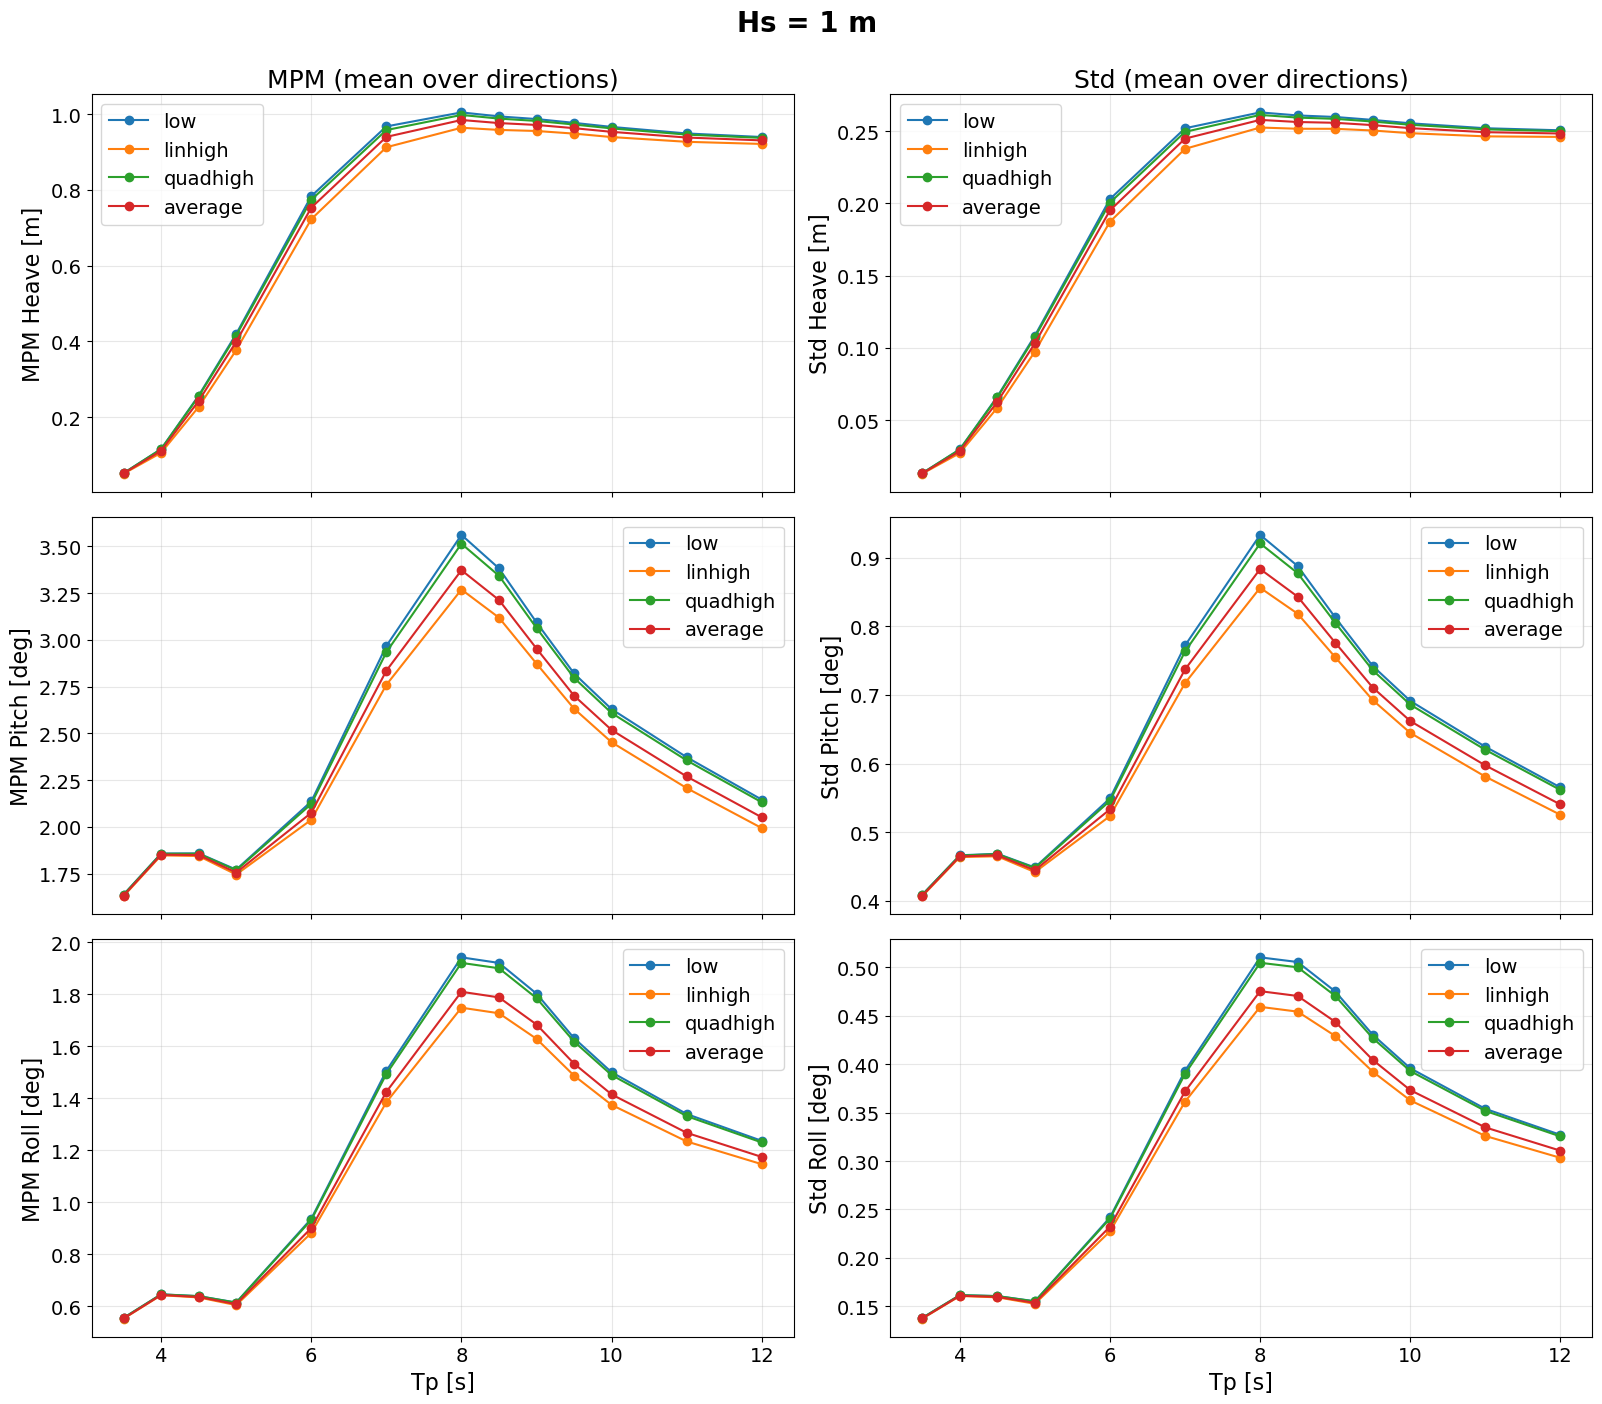

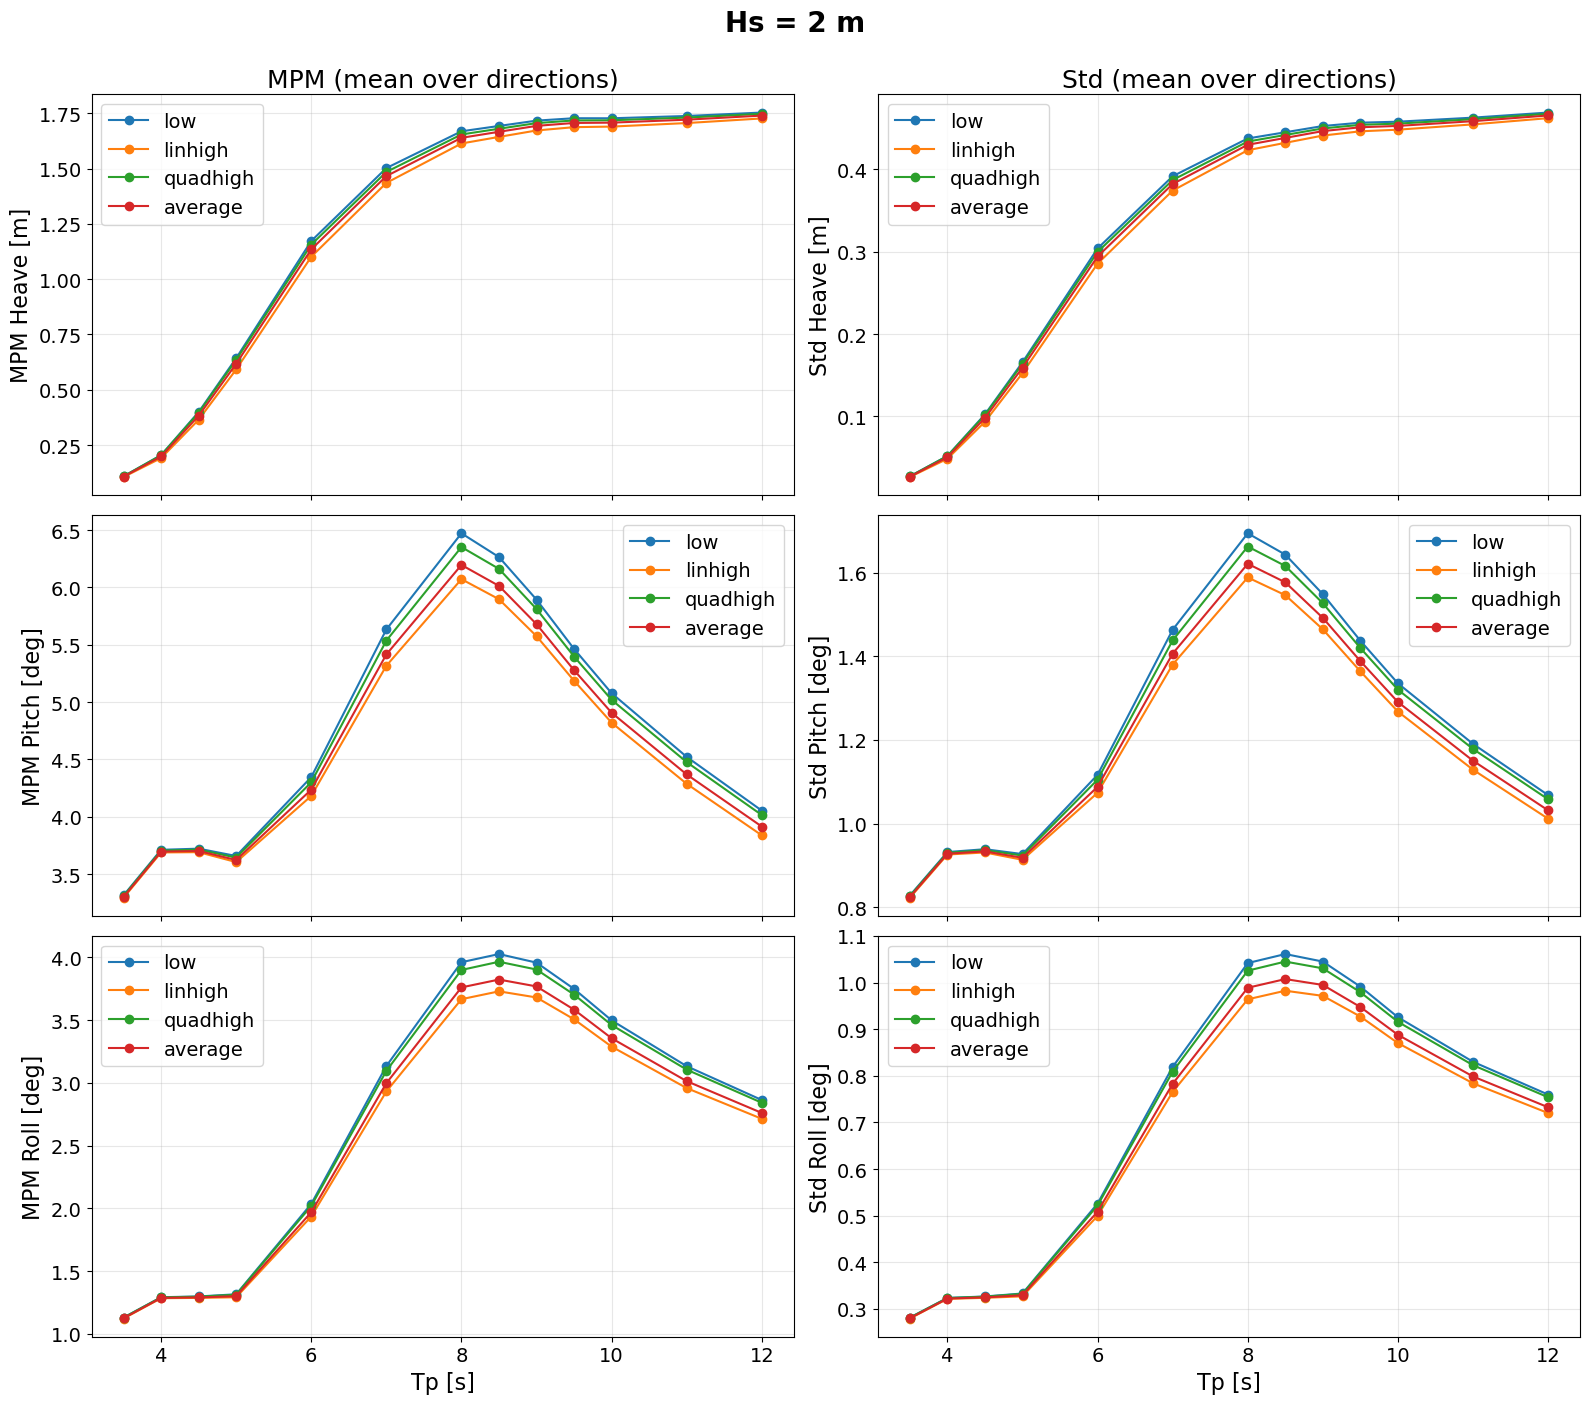

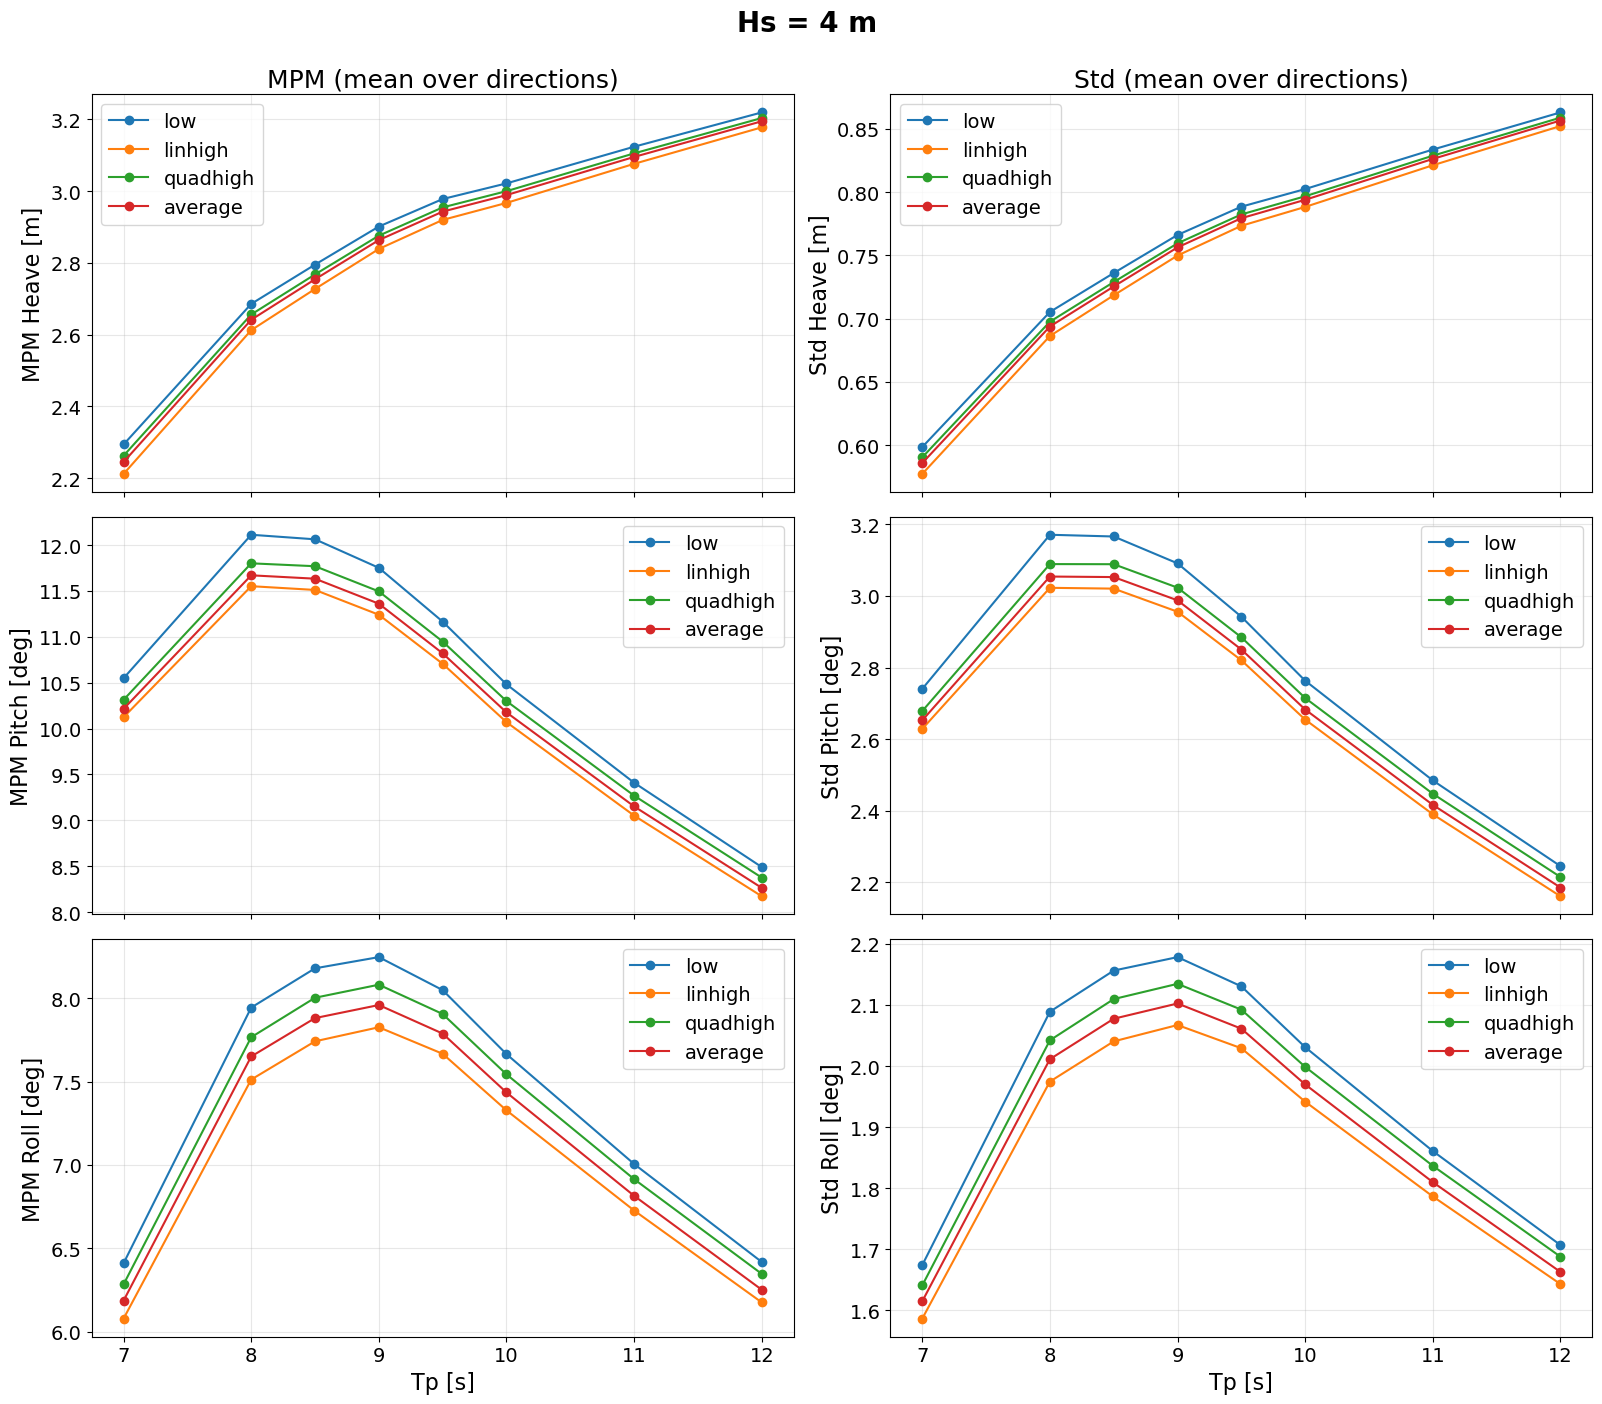

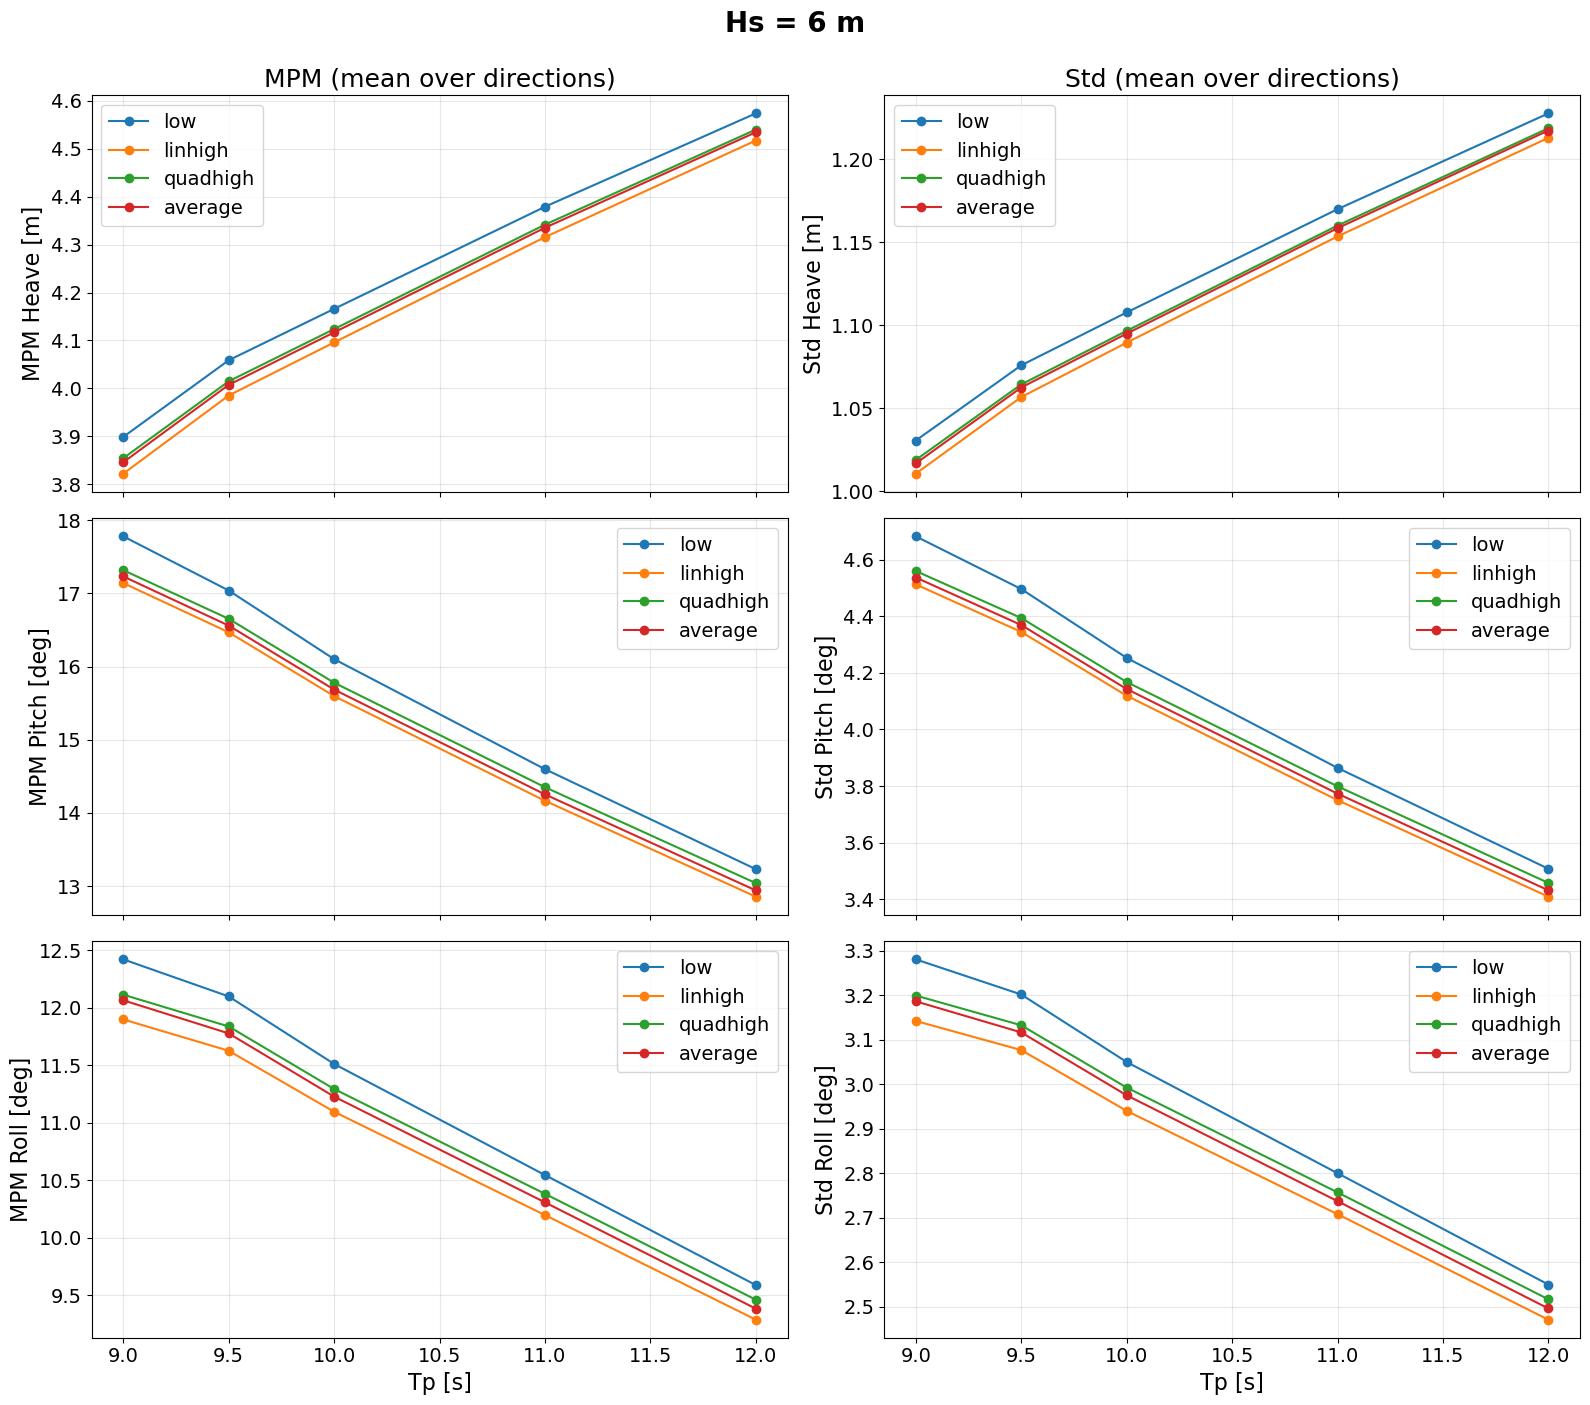

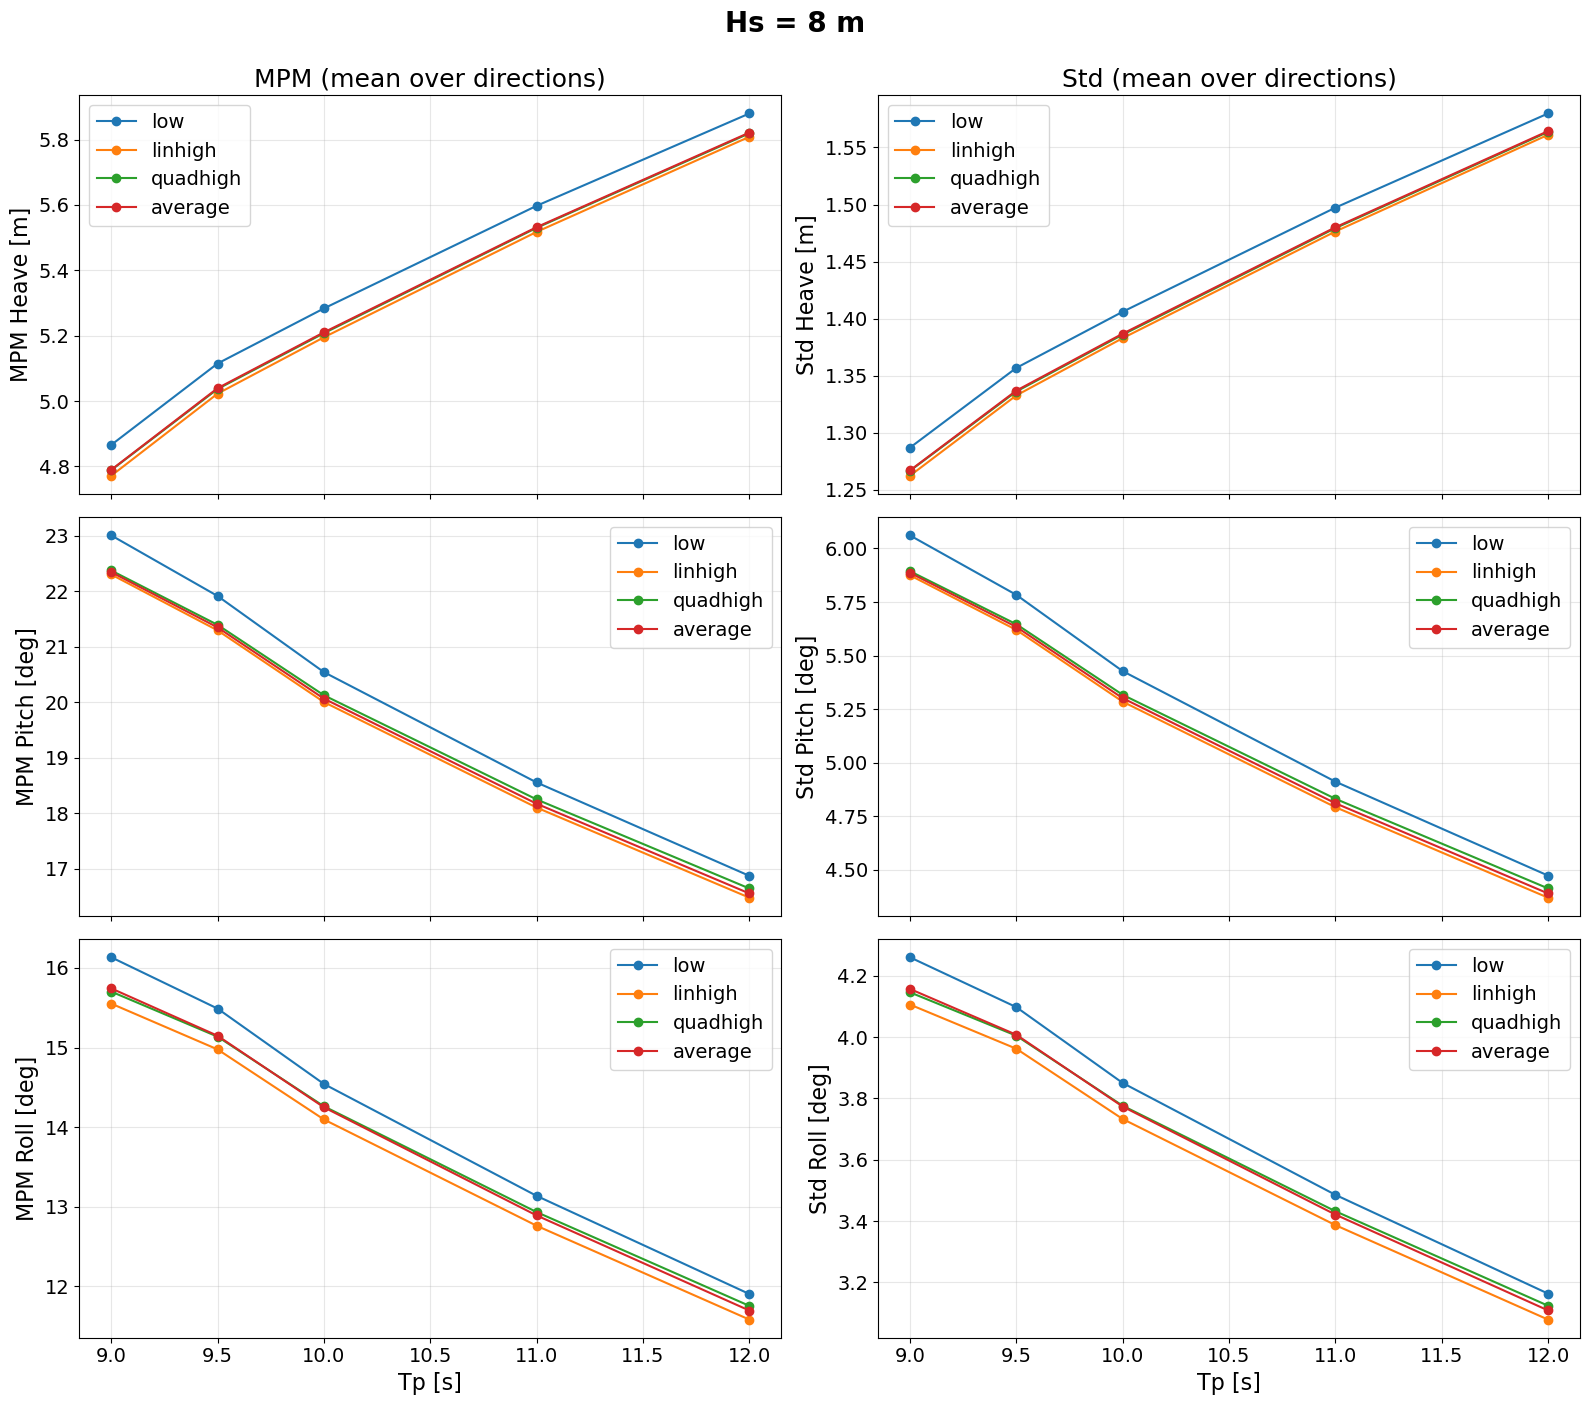

In [5]:
def plot_mpm_std_per_hs(df, hs):
    fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
    sub_hs = df[df['Hs'] == hs]

    for r, dof in enumerate(DOFS):
        sub_dof = filter_dirs(sub_hs, dof)
        dcol = damping_col(dof['key'])
        mpm_c = f'MPM {dof["key"]} corr'
        std_c = std_col(dof['key'])

        for case in DAMPING_CASES:
            sub_case = sub_dof[sub_dof[dcol] == case]
            if sub_case.empty:
                continue
            grouped = sub_case.groupby('Tp')[[mpm_c, std_c]].mean().sort_index()
            color = DAMPING_COLORS[case]

            axes[r, 0].plot(grouped.index, grouped[mpm_c], 'o-', label=case, color=color)
            axes[r, 1].plot(grouped.index, grouped[std_c], 'o-', label=case, color=color)

        axes[r, 0].set_ylabel(f'MPM {dof["name"]} [{dof["unit"]}]')
        axes[r, 1].set_ylabel(f'Std {dof["name"]} [{dof["unit"]}]')
        axes[r, 0].grid(True, alpha=0.3)
        axes[r, 1].grid(True, alpha=0.3)
        axes[r, 0].legend()
        axes[r, 1].legend()

    axes[2, 0].set_xlabel('Tp [s]')
    axes[2, 1].set_xlabel('Tp [s]')
    axes[0, 0].set_title('MPM (mean over directions)')
    axes[0, 1].set_title('Std (mean over directions)')
    fig.suptitle(f'Hs = {hs} m', y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
    fig.tight_layout()
    return fig

for hs in HS_VALUES:
    plot_mpm_std_per_hs(df, hs)
plt.show()

## 3. MPM and Std per direction (low damping only)

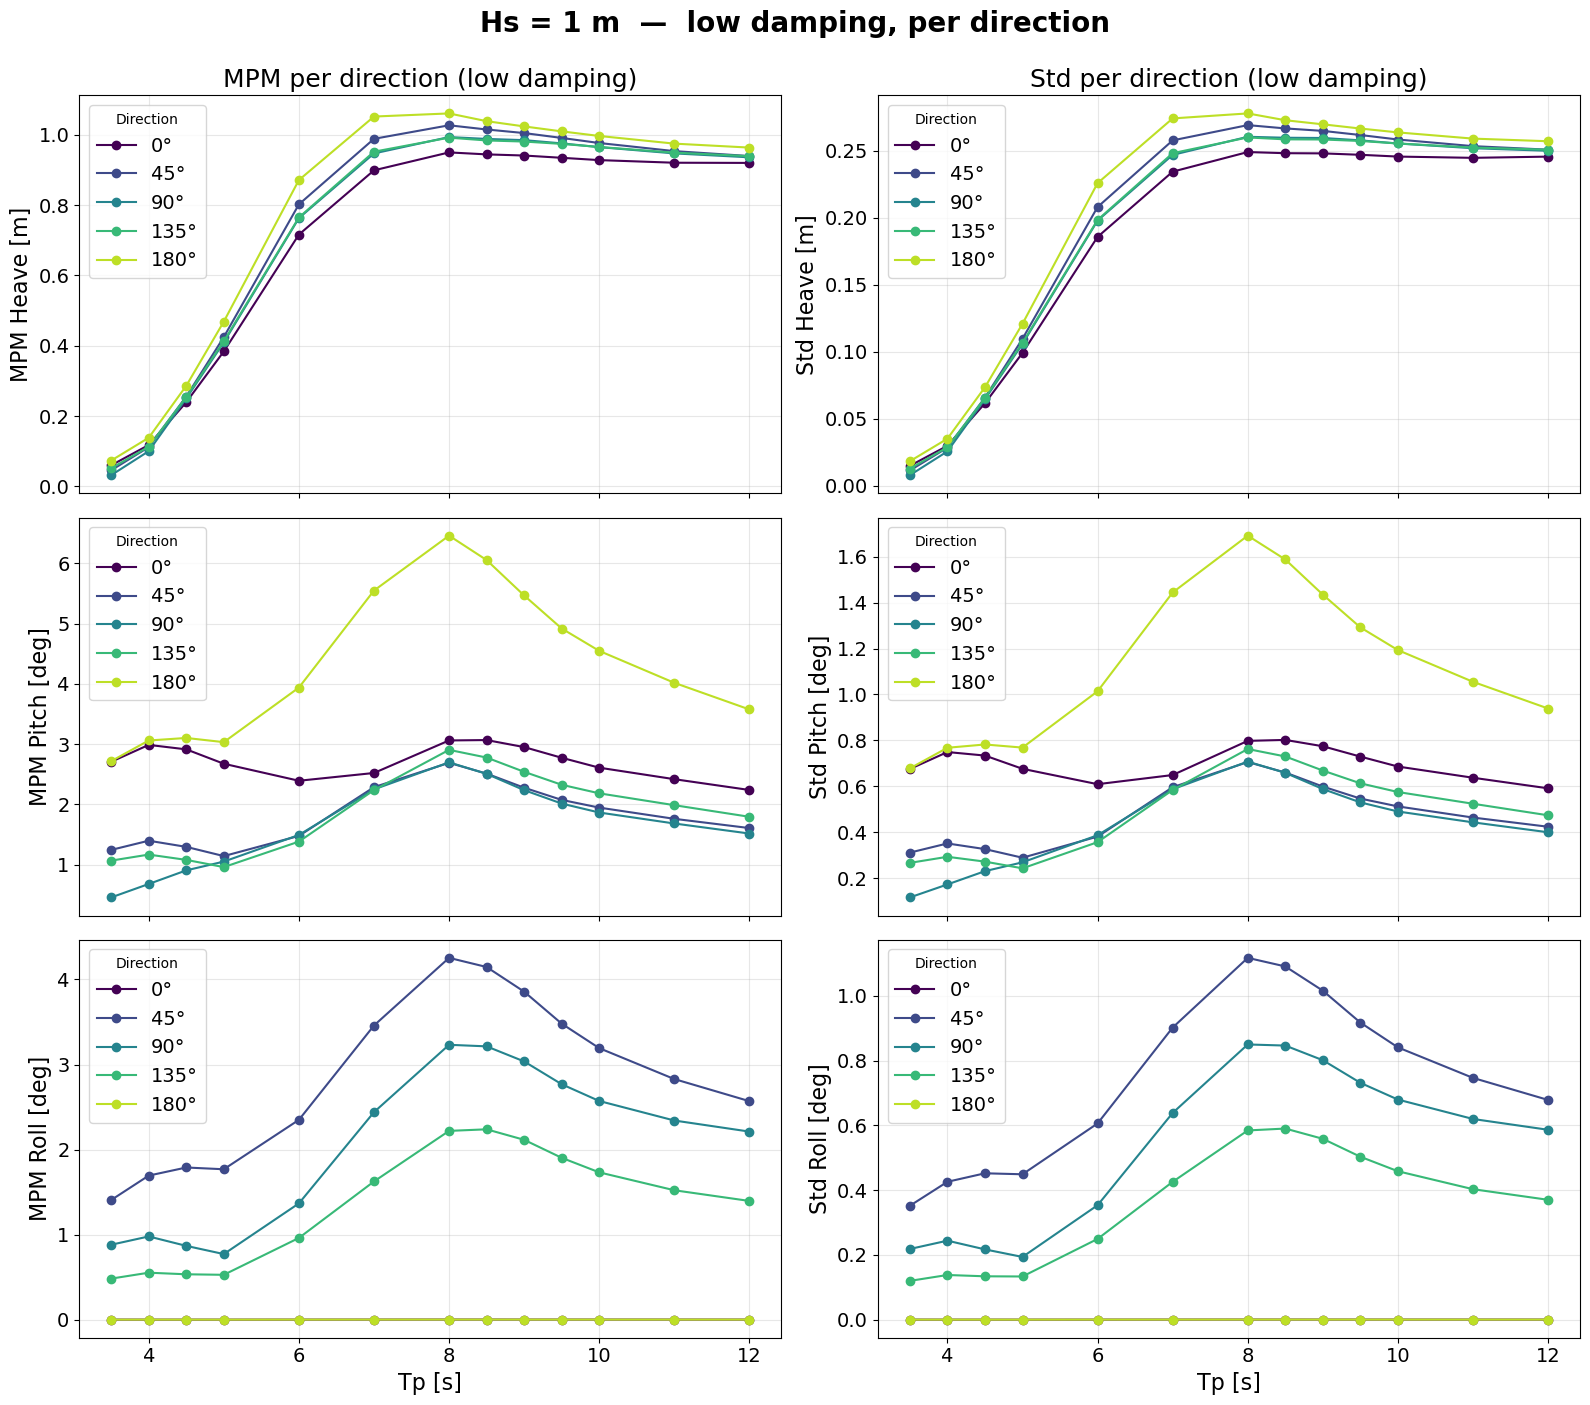

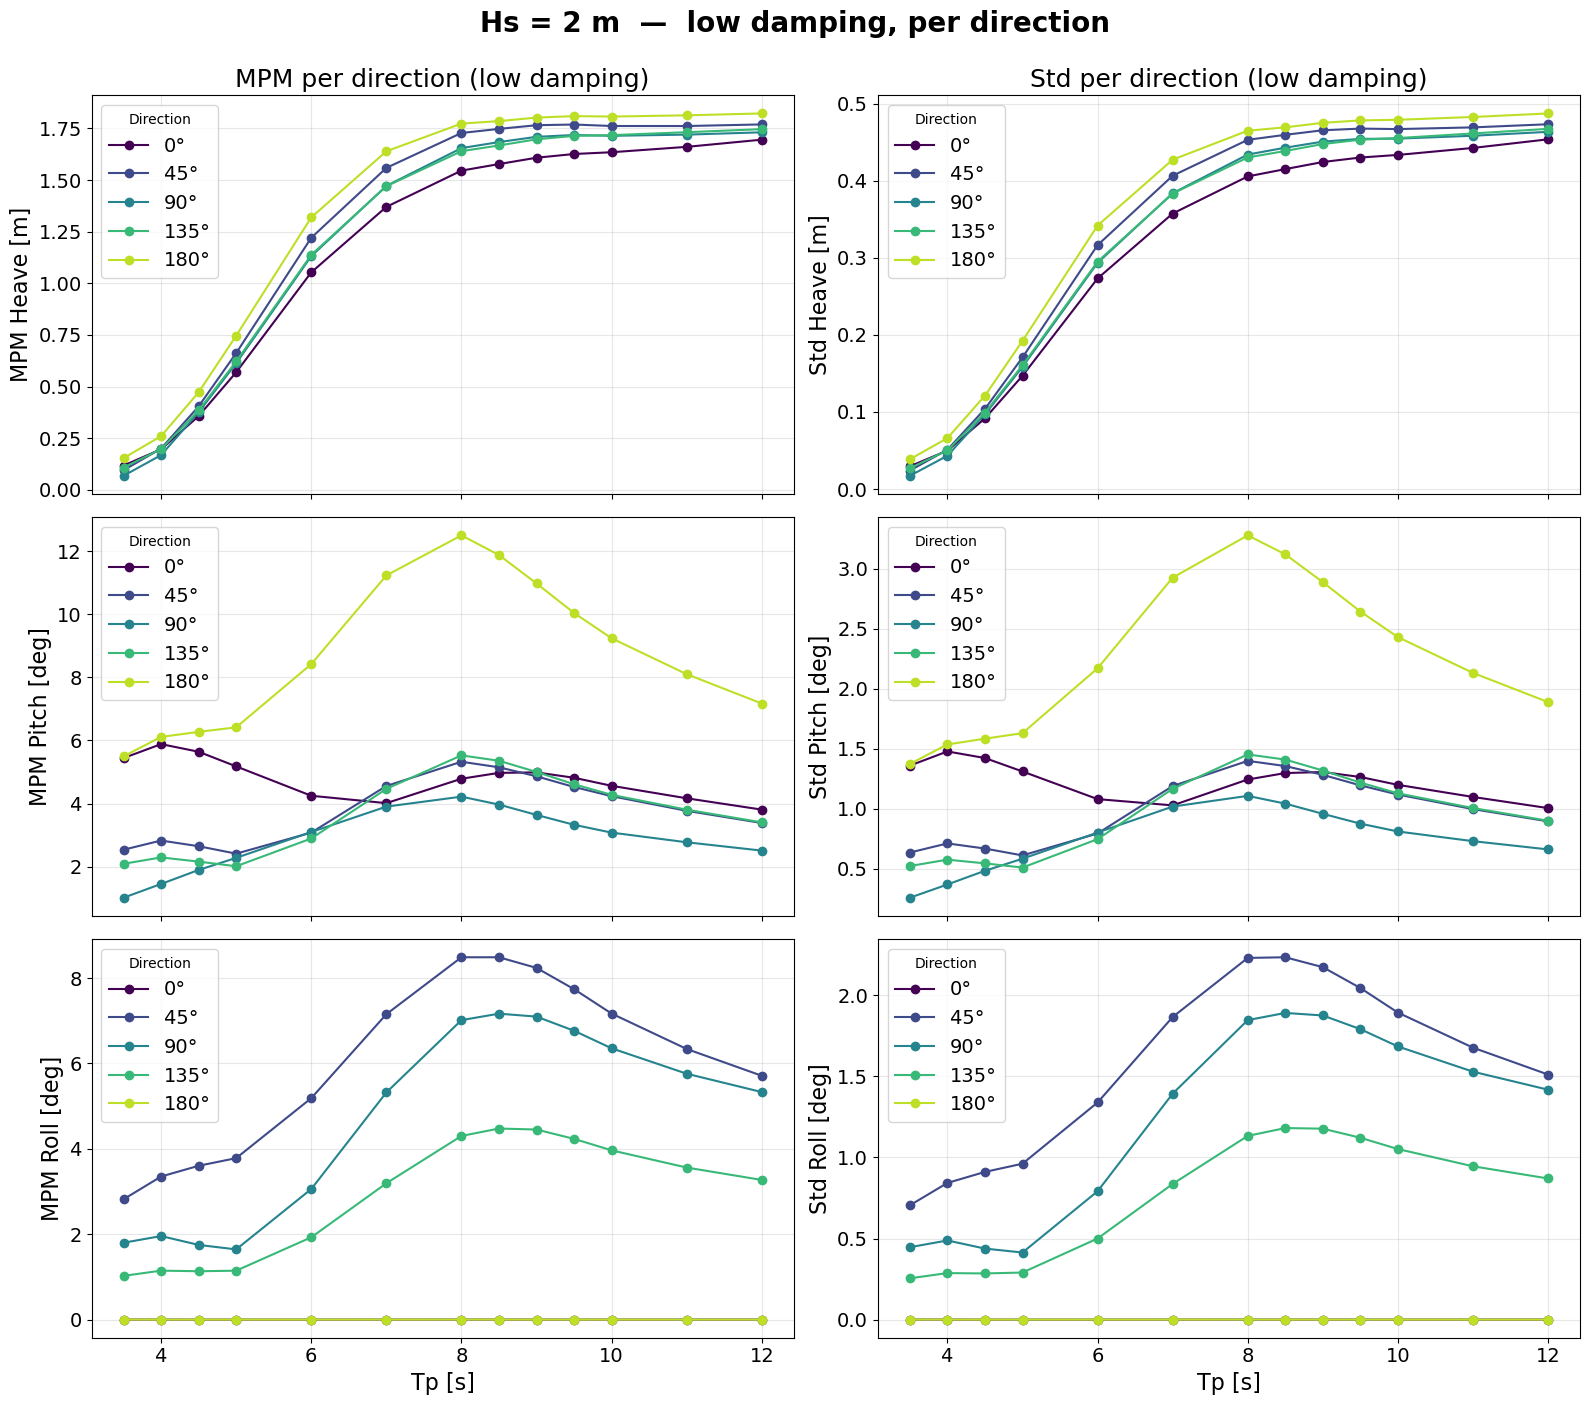

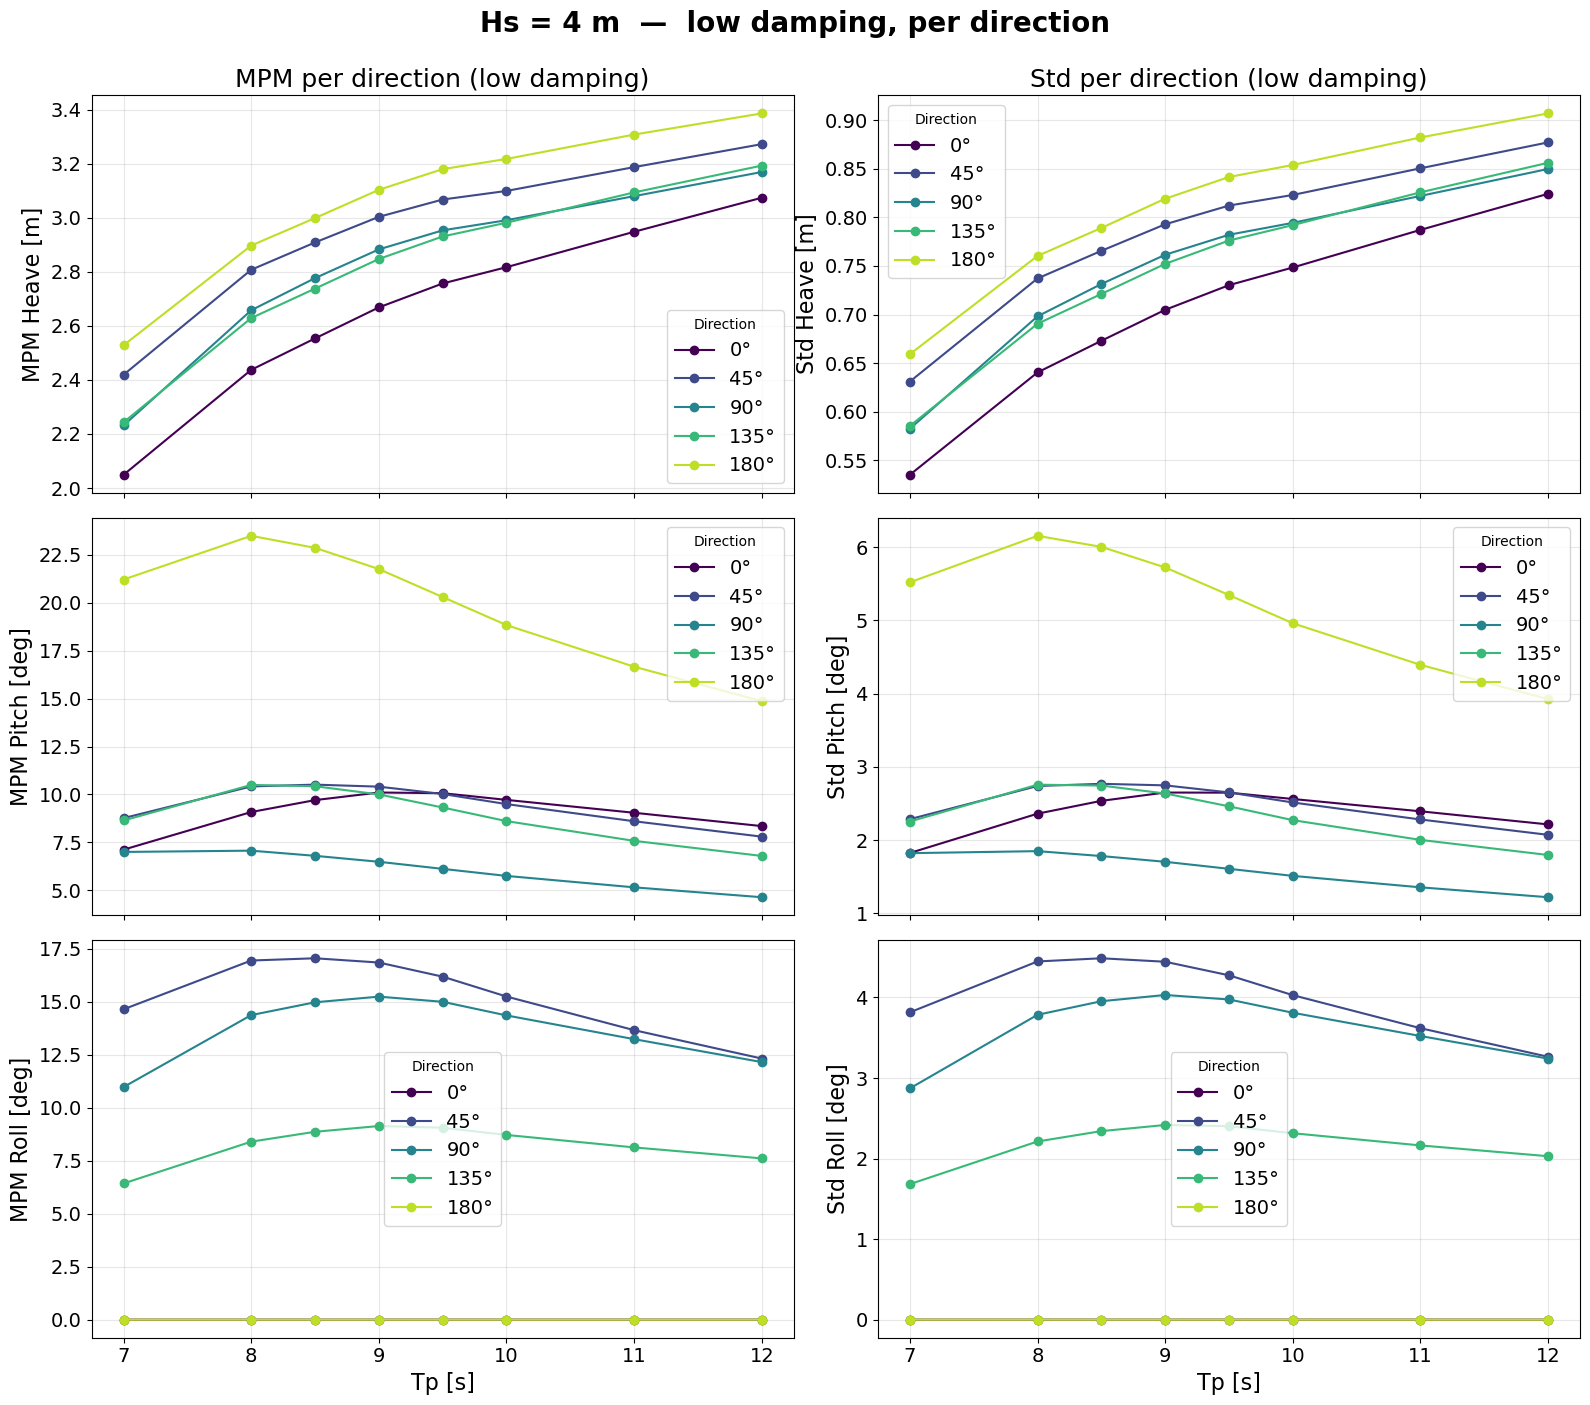

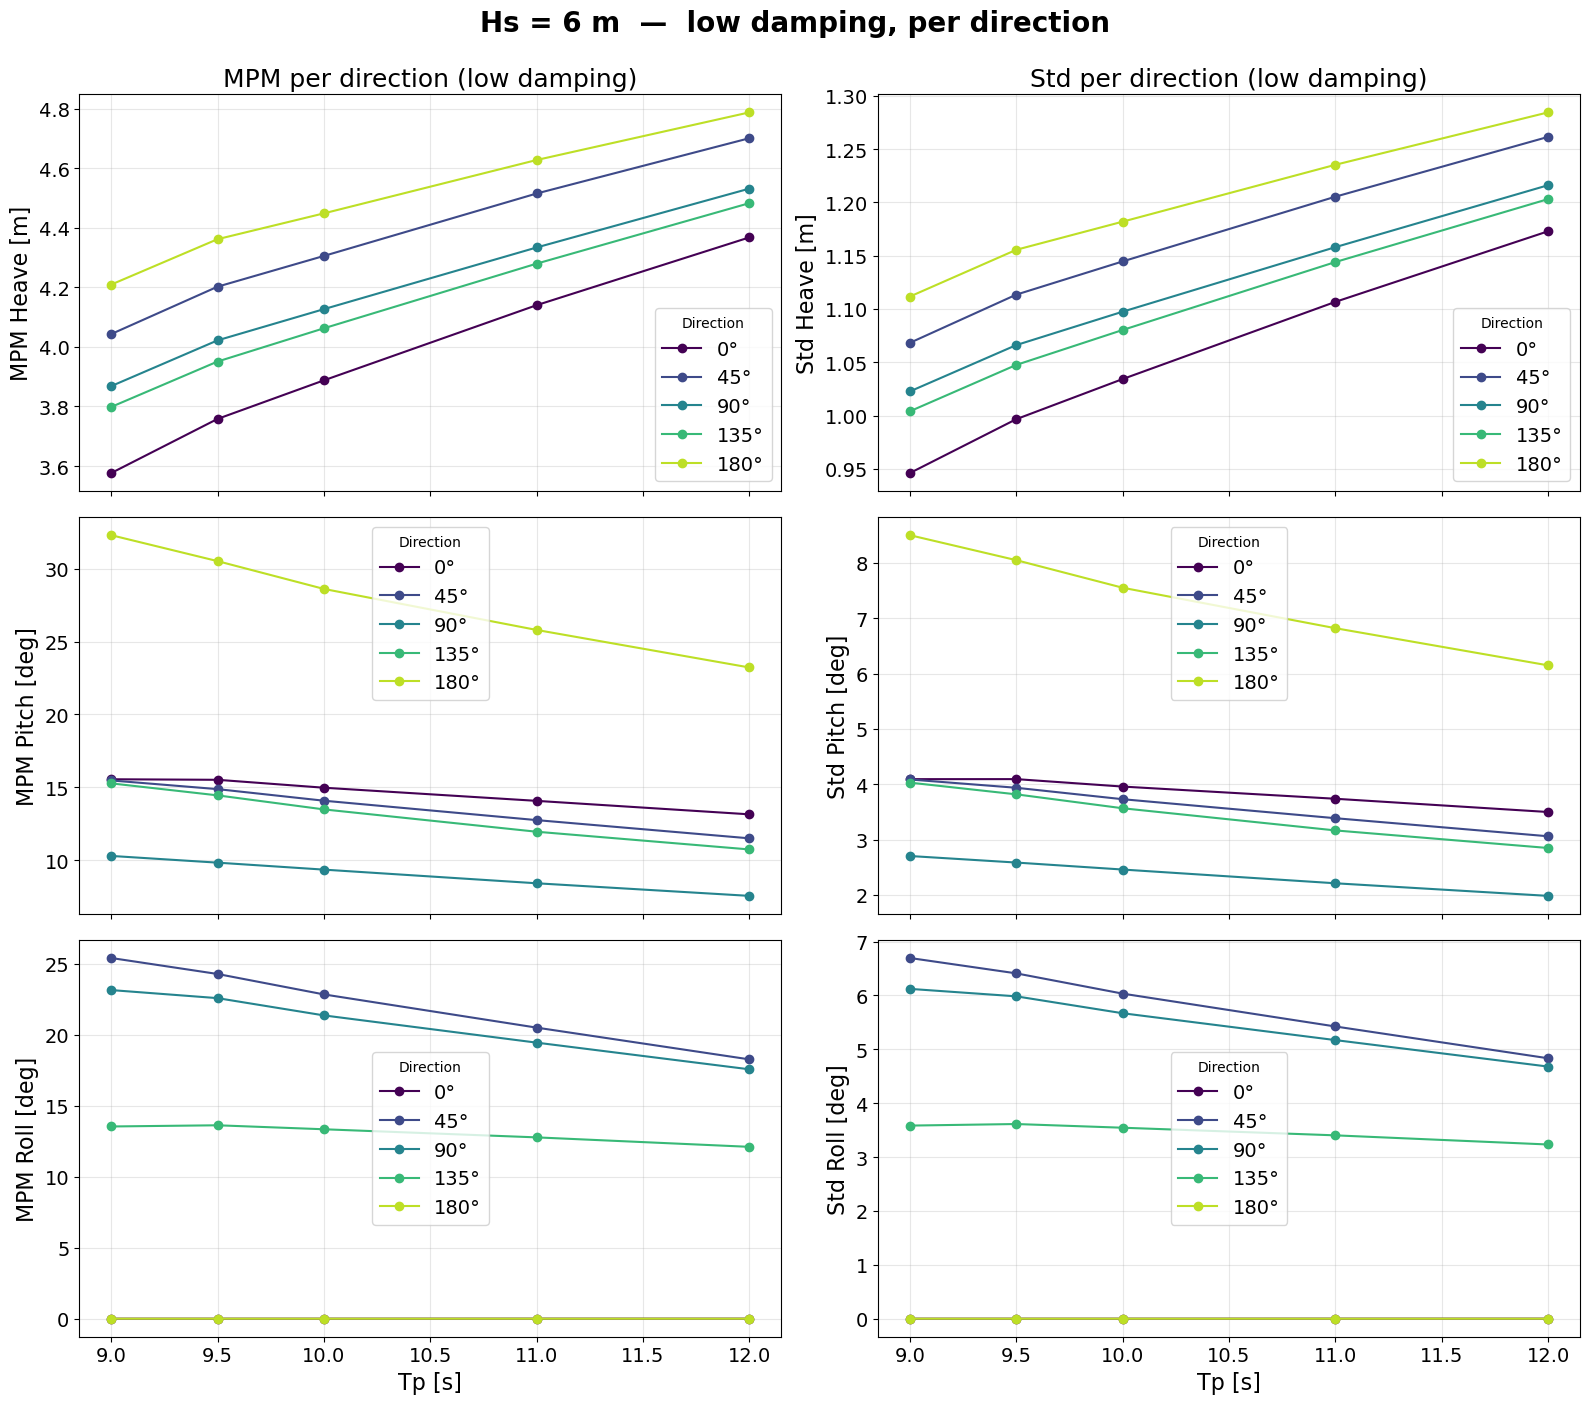

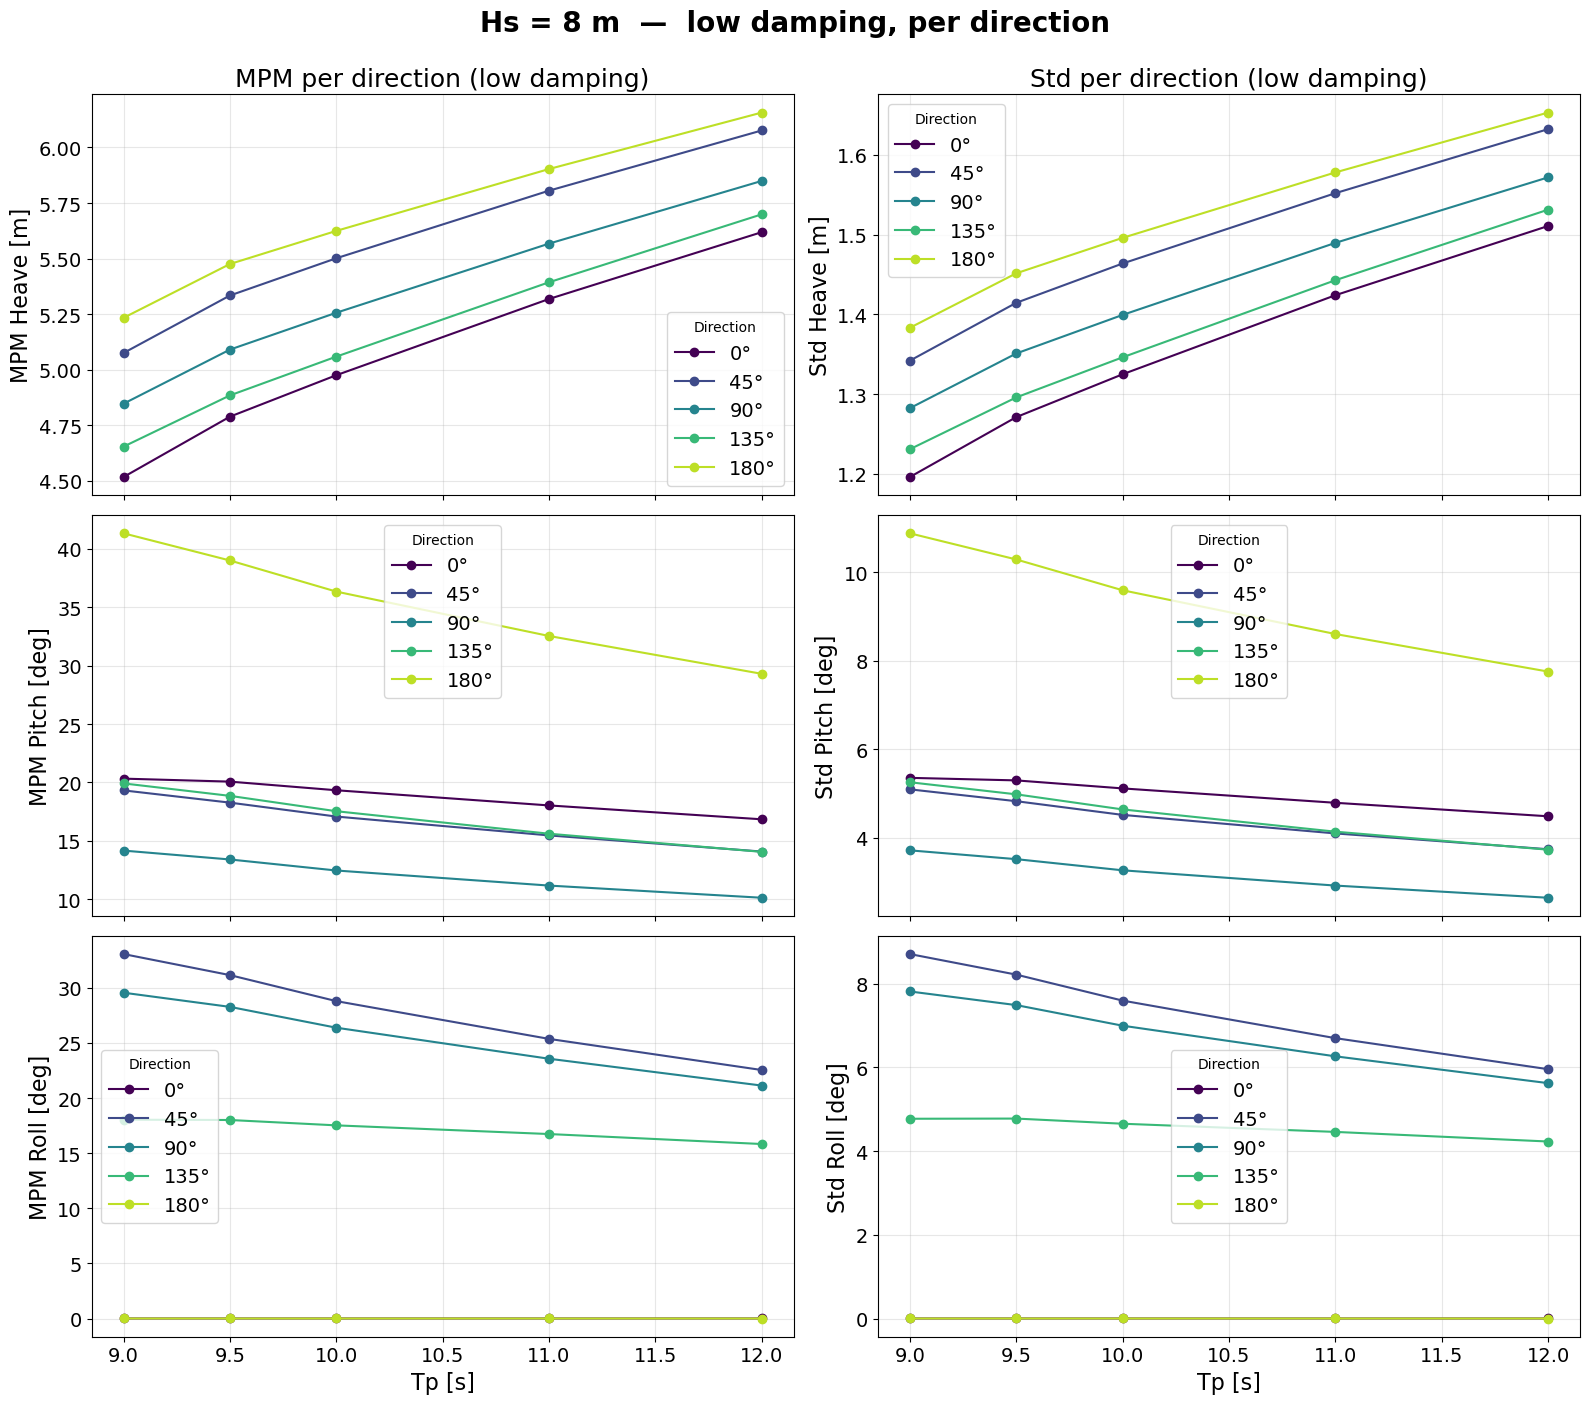

In [6]:
DIRECTIONS = sorted(df['Direction'].unique())
DIR_COLORS = plt.cm.viridis(np.linspace(0, 0.9, len(DIRECTIONS)))

for hs in HS_VALUES:
    fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
    sub_hs = df[(df['Hs'] == hs) & (df['Damp_Heave'] == 'low')]

    for r, dof in enumerate(DOFS):
        mpm_c = f'MPM {dof["key"]} corr'
        std_c = std_col(dof['key'])

        for d, direction in enumerate(DIRECTIONS):
            sub_dir = sub_hs[sub_hs['Direction'] == direction].sort_values('Tp')
            if sub_dir.empty:
                continue
            axes[r, 0].plot(sub_dir['Tp'], sub_dir[mpm_c], 'o-',
                            label=f'{direction}°', color=DIR_COLORS[d])
            axes[r, 1].plot(sub_dir['Tp'], sub_dir[std_c], 'o-',
                            label=f'{direction}°', color=DIR_COLORS[d])

        axes[r, 0].set_ylabel(f'MPM {dof["name"]} [{dof["unit"]}]')
        axes[r, 1].set_ylabel(f'Std {dof["name"]} [{dof["unit"]}]')
        axes[r, 0].grid(True, alpha=0.3)
        axes[r, 1].grid(True, alpha=0.3)
        axes[r, 0].legend(title='Direction')
        axes[r, 1].legend(title='Direction')

    axes[2, 0].set_xlabel('Tp [s]')
    axes[2, 1].set_xlabel('Tp [s]')
    axes[0, 0].set_title('MPM per direction (low damping)')
    axes[0, 1].set_title('Std per direction (low damping)')
    fig.suptitle(f'Hs = {hs} m  —  low damping, per direction',
                 y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
    fig.tight_layout()

plt.show()

## 4. Percentage difference vs the `low` case (6 subplots per Hs)

Computed as `(case - low) / low * 100` per Tp, after averaging over directions.  
The `low` case itself is the baseline and is not drawn, so each subplot has 3 lines.

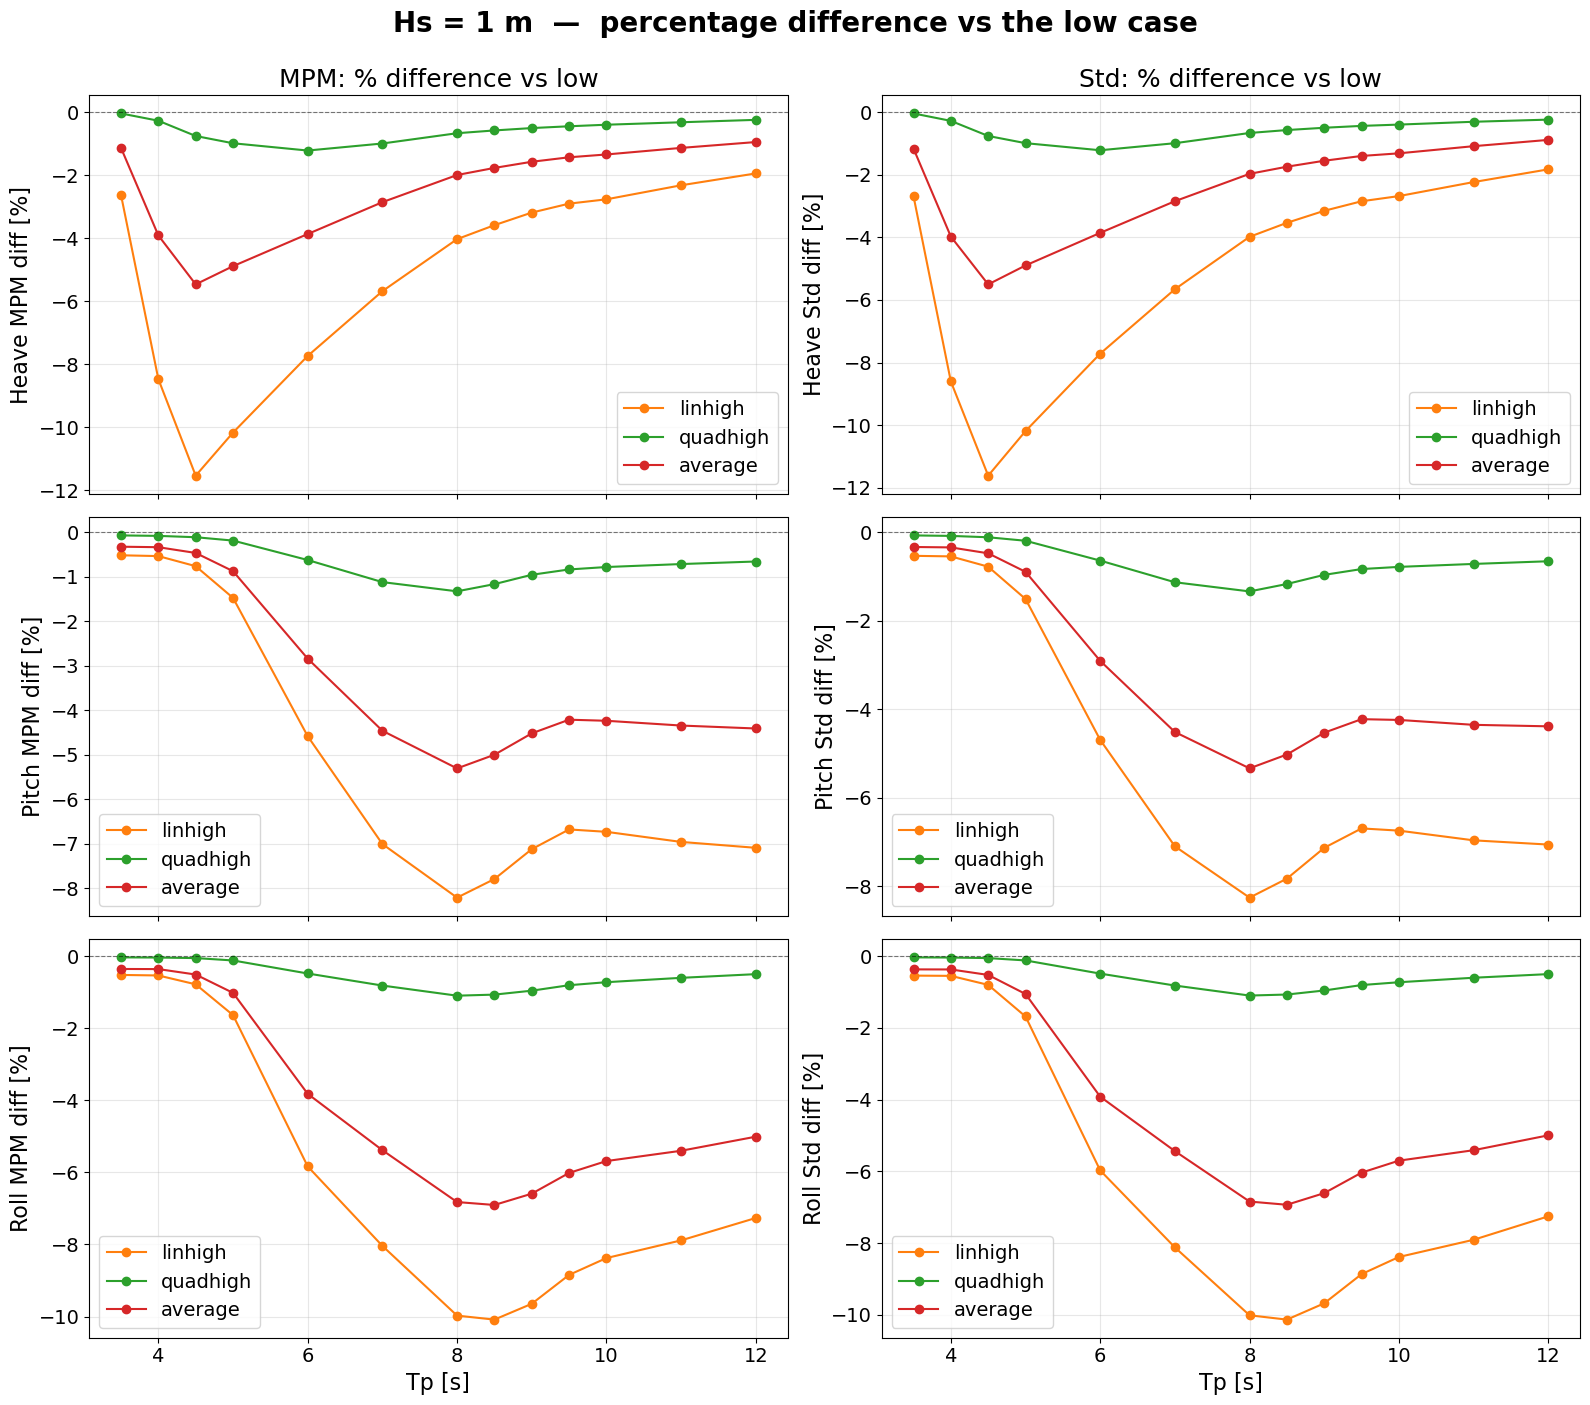

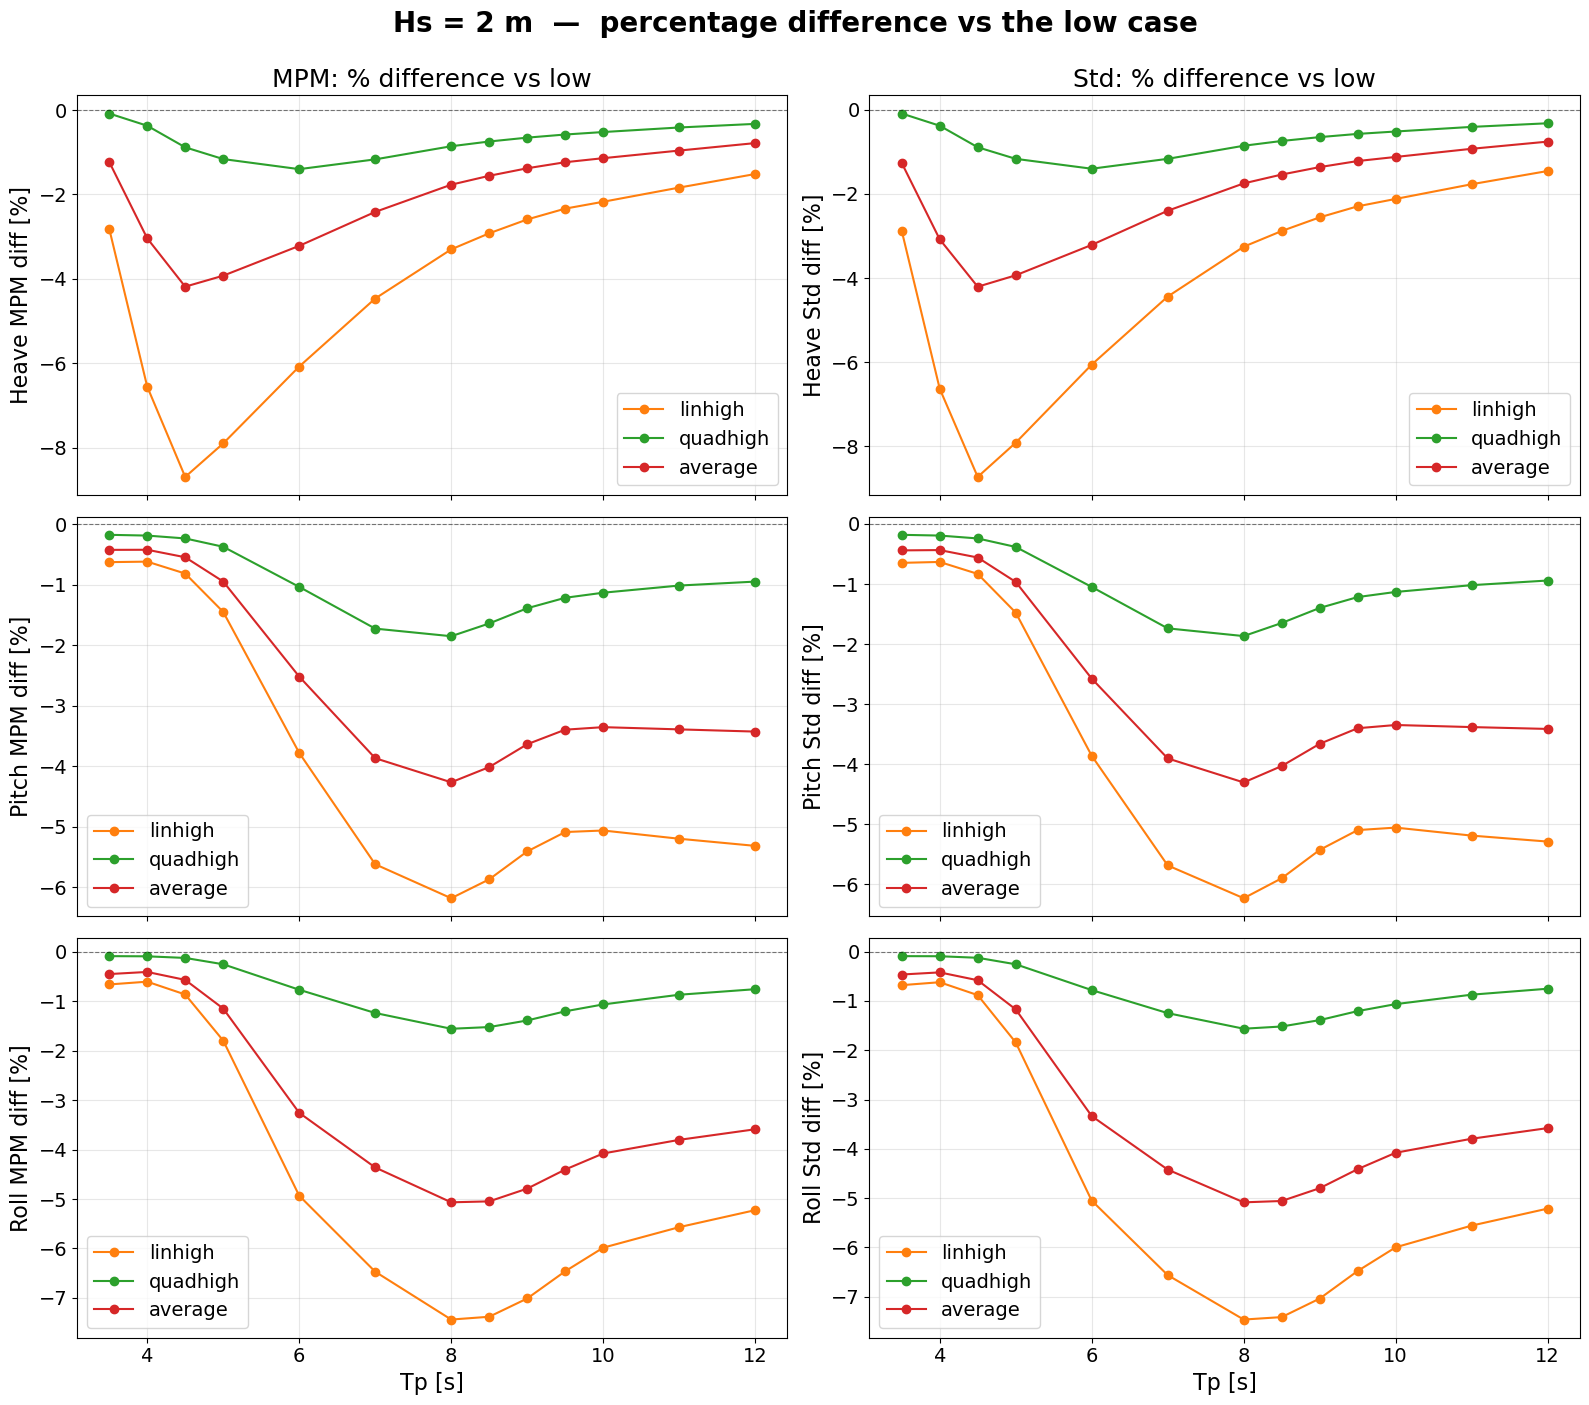

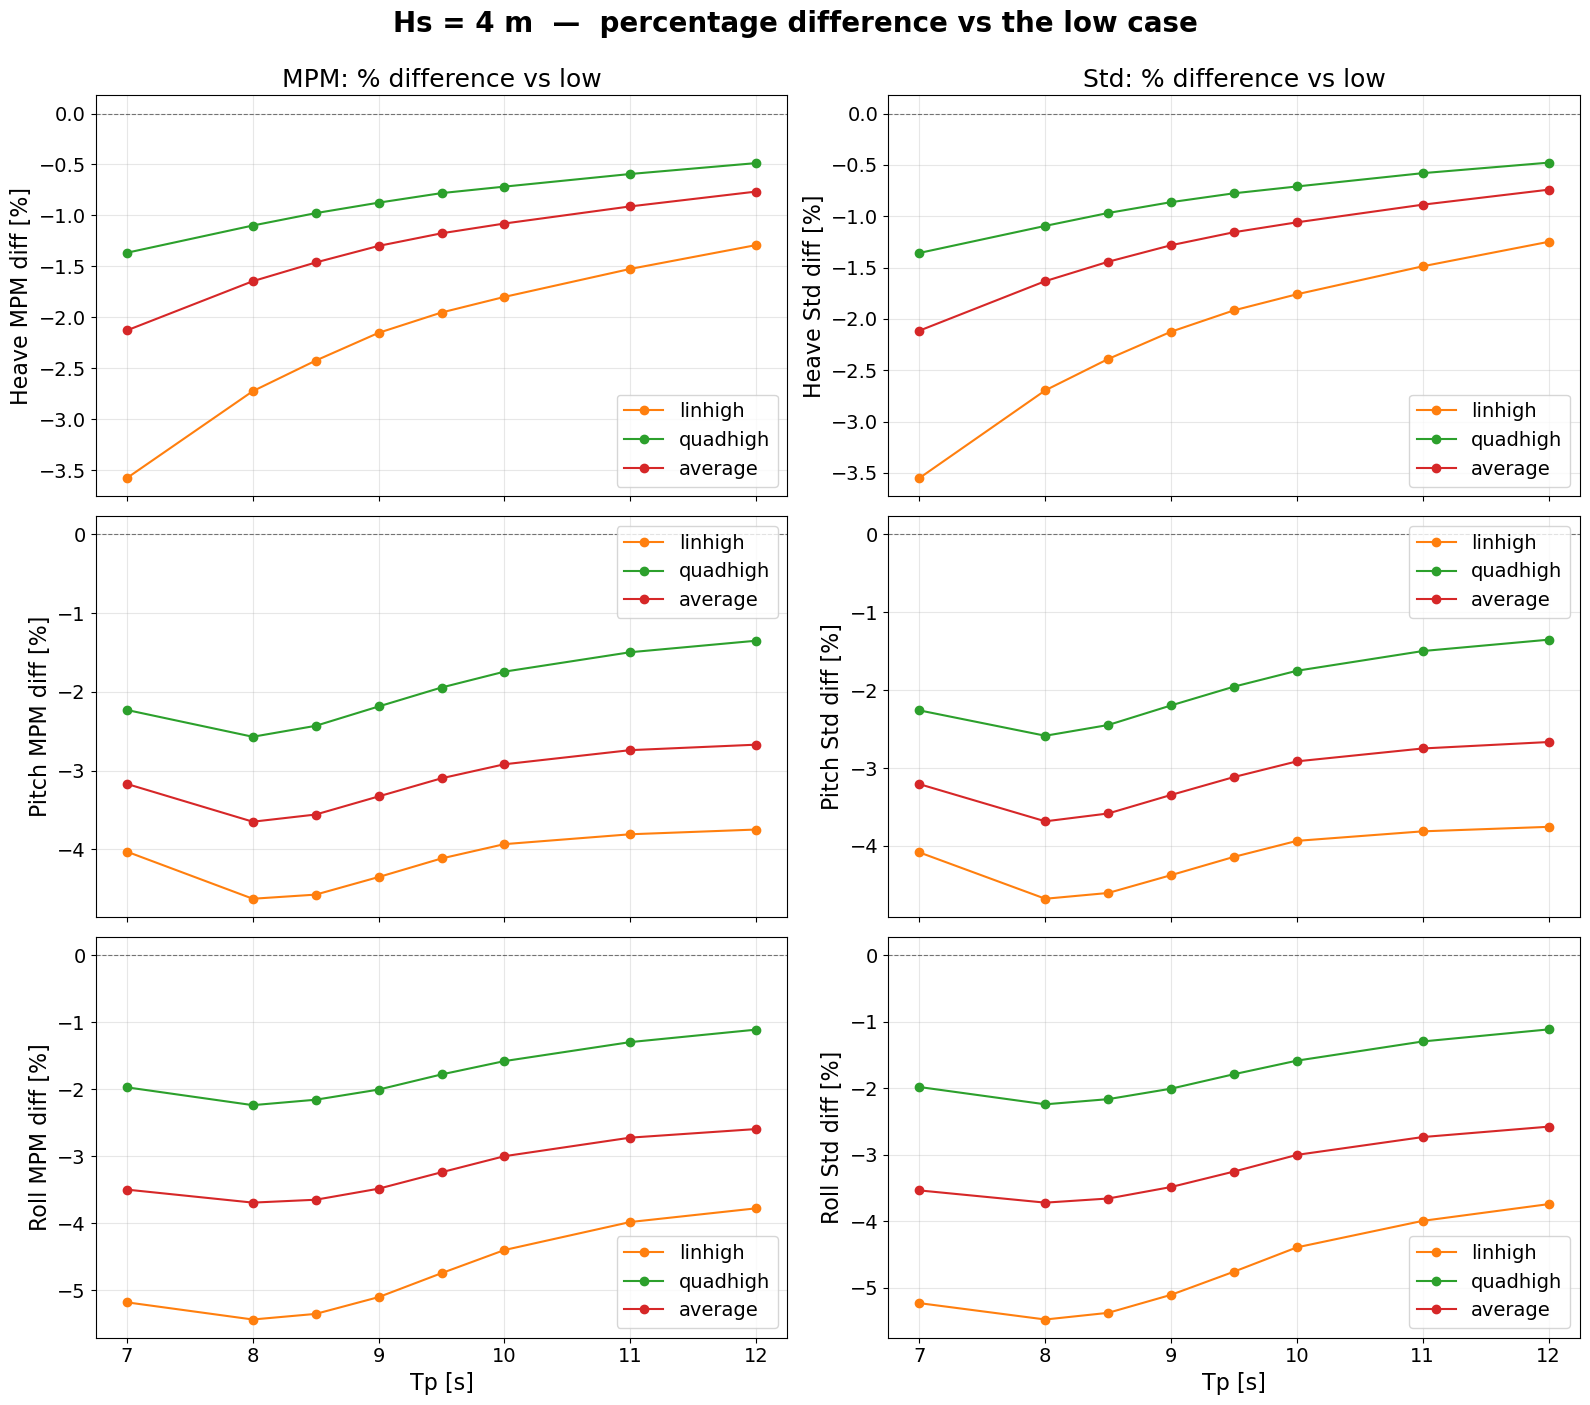

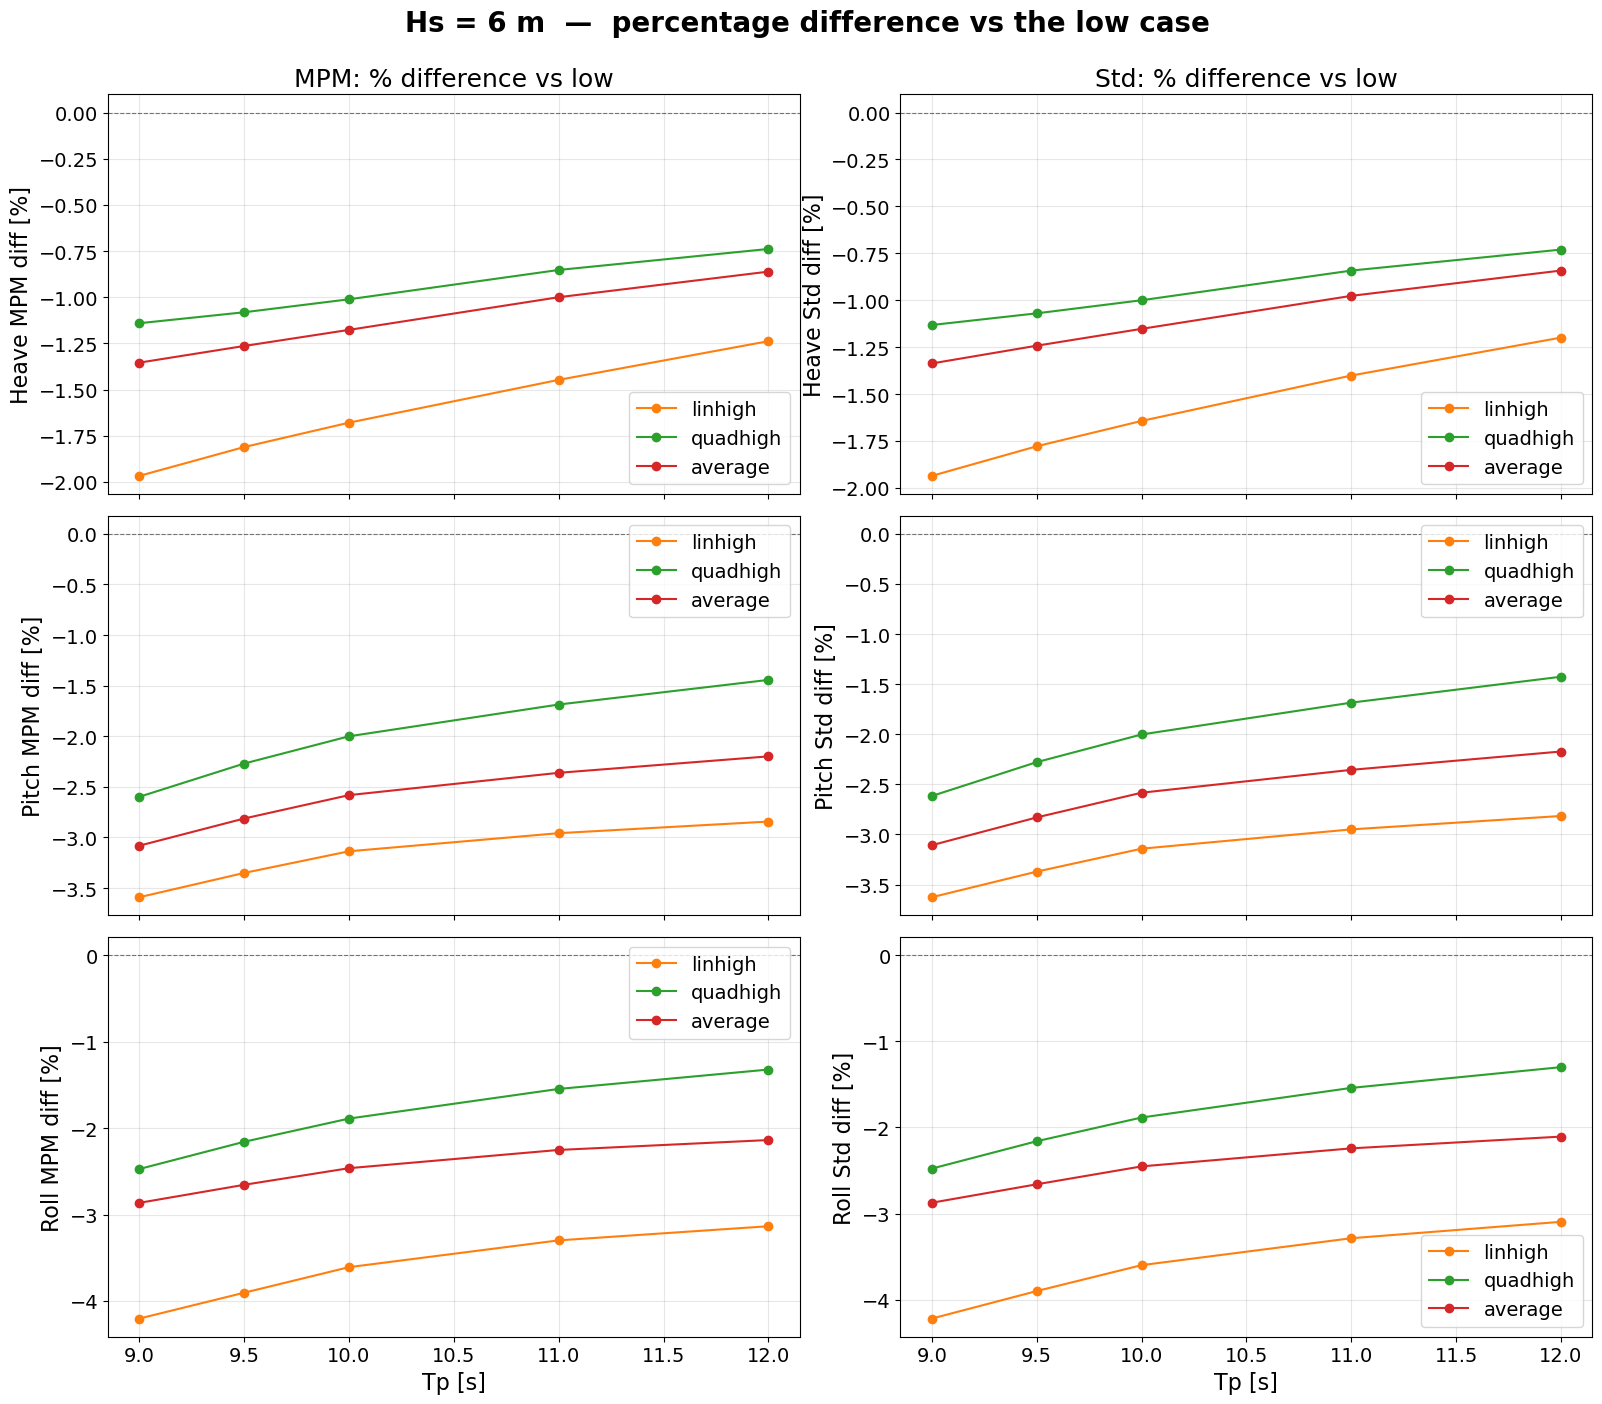

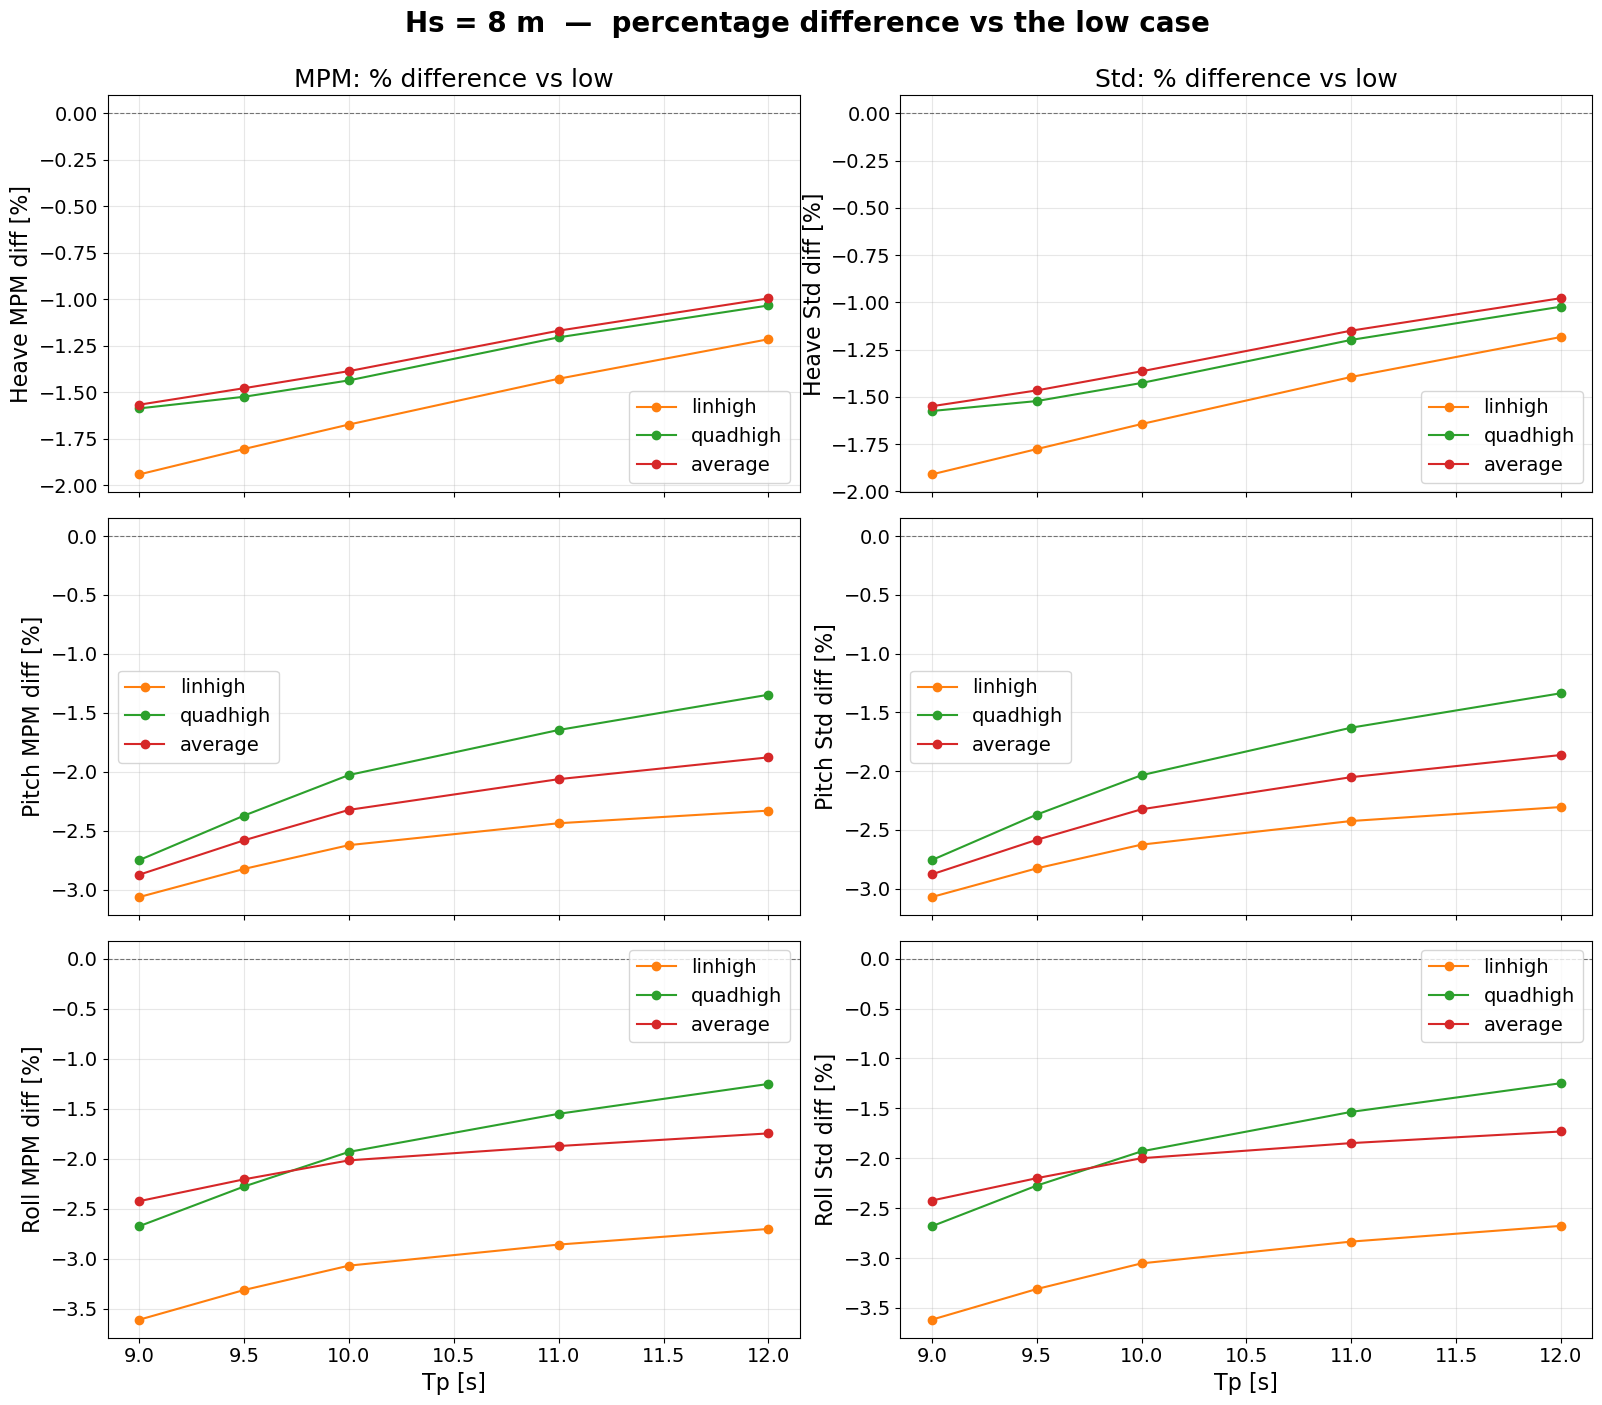

In [7]:
def plot_pct_diff_per_hs(df, hs):
    fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
    sub_hs = df[df['Hs'] == hs]

    for r, dof in enumerate(DOFS):
        sub_dof = filter_dirs(sub_hs, dof)
        dcol = damping_col(dof['key'])
        mpm_c = f'MPM {dof["key"]} corr'
        std_c = std_col(dof['key'])

        # baseline: low
        base = sub_dof[sub_dof[dcol] == 'low'].groupby('Tp')[[mpm_c, std_c]].mean().sort_index()

        for case in ['linhigh', 'quadhigh', 'average']:
            sub_case = sub_dof[sub_dof[dcol] == case]
            if sub_case.empty:
                continue
            grouped = sub_case.groupby('Tp')[[mpm_c, std_c]].mean().sort_index()
            common_tp = grouped.index.intersection(base.index)
            if len(common_tp) == 0:
                continue
            pct_mpm = (grouped.loc[common_tp, mpm_c] - base.loc[common_tp, mpm_c]) / base.loc[common_tp, mpm_c] * 100
            pct_std = (grouped.loc[common_tp, std_c] - base.loc[common_tp, std_c]) / base.loc[common_tp, std_c] * 100
            color = DAMPING_COLORS[case]

            axes[r, 0].plot(common_tp, pct_mpm, 'o-', label=case, color=color)
            axes[r, 1].plot(common_tp, pct_std, 'o-', label=case, color=color)

        axes[r, 0].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        axes[r, 1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        axes[r, 0].set_ylabel(f'{dof["name"]} MPM diff [%]')
        axes[r, 1].set_ylabel(f'{dof["name"]} Std diff [%]')
        axes[r, 0].grid(True, alpha=0.3)
        axes[r, 1].grid(True, alpha=0.3)
        axes[r, 0].legend()
        axes[r, 1].legend()

    axes[2, 0].set_xlabel('Tp [s]')
    axes[2, 1].set_xlabel('Tp [s]')
    axes[0, 0].set_title('MPM: % difference vs low')
    axes[0, 1].set_title('Std: % difference vs low')
    fig.suptitle(f'Hs = {hs} m  —  percentage difference vs the low case', y=1.00,
                 fontsize=TITLE_SIZE + 2, fontweight='bold')
    fig.tight_layout()
    return fig

for hs in HS_VALUES:
    plot_pct_diff_per_hs(df, hs)
plt.show()

## 5. Most extreme MPM per DOF (max over directions) for all damping cases

For every (Hs, Tp, damping case), take the **max** of `|MPM − mean|` across directions.  
One subplot per DOF, one line per damping case, different markers per Hs.

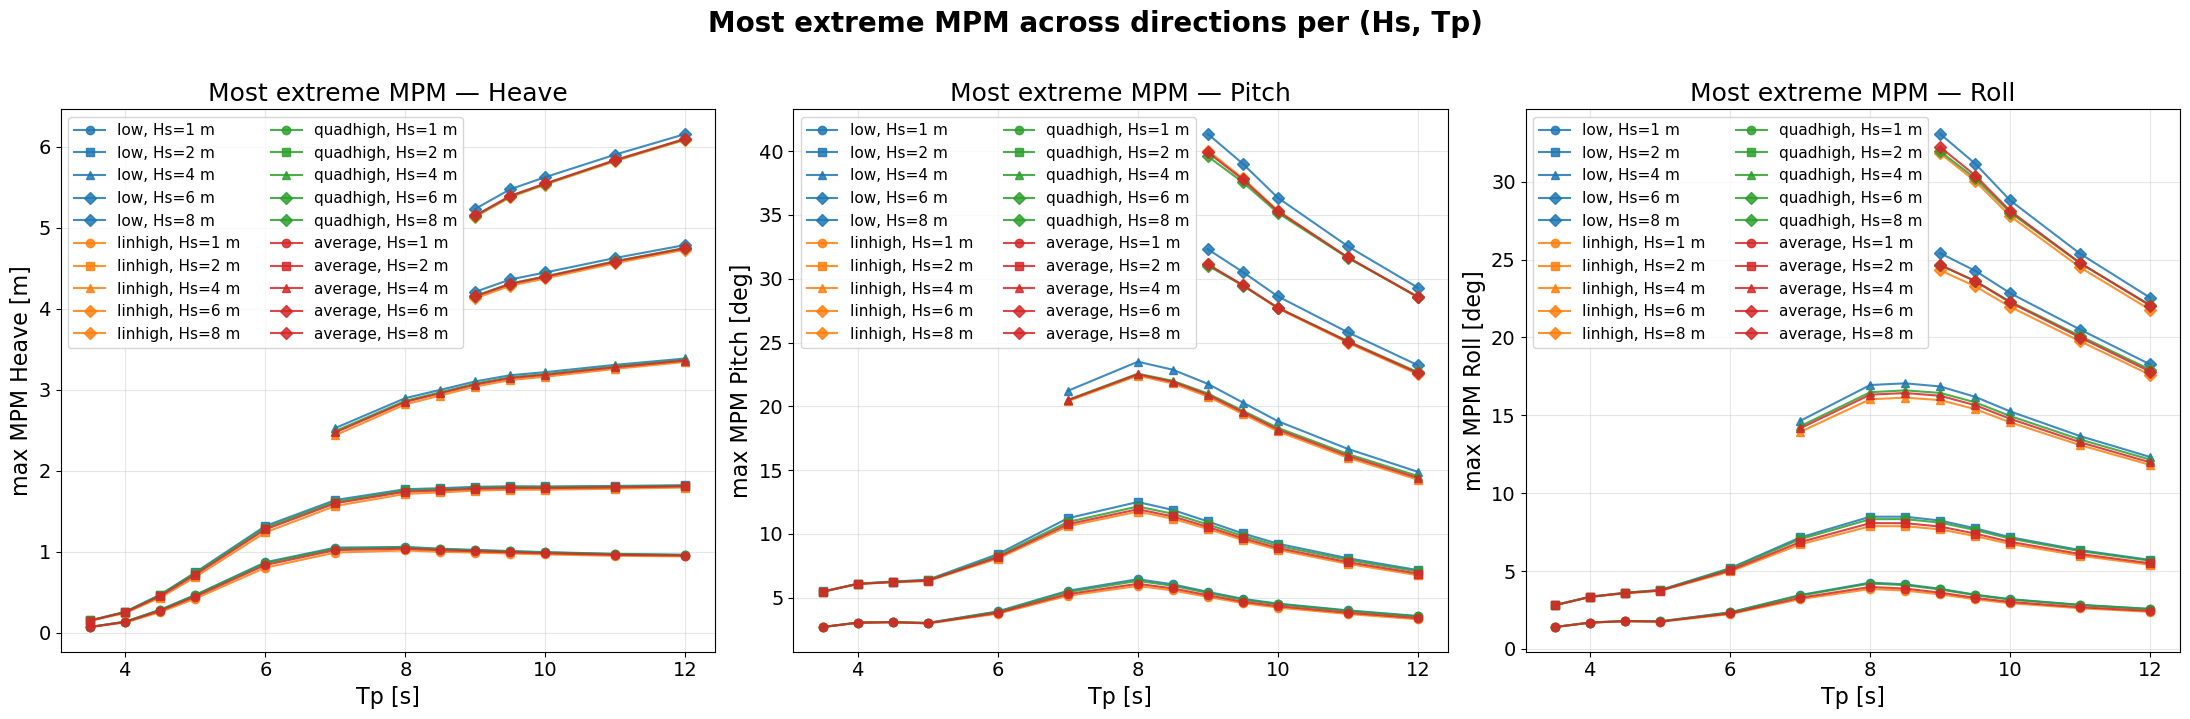

In [8]:
HS_MARKERS = {1: 'o', 2: 's', 4: '^'}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    for case in DAMPING_CASES:
        sub_case = sub_dof[sub_dof[dcol] == case]
        if sub_case.empty:
            continue
        extremes = sub_case.groupby(['Hs', 'Tp'])[mpm_c].max().reset_index()
        color = DAMPING_COLORS[case]

        for hs in HS_VALUES:
            sub_hs = extremes[extremes['Hs'] == hs].sort_values('Tp')
            if sub_hs.empty:
                continue
            marker = HS_MARKERS.get(hs, 'D')
            label = f'{case}, Hs={hs} m'
            ax.plot(sub_hs['Tp'], sub_hs[mpm_c],
                    marker=marker, linestyle='-',
                    color=color, label=label, alpha=0.85)

    ax.set_title(f'Most extreme MPM — {dof["name"]}')
    ax.set_xlabel('Tp [s]')
    ax.set_ylabel(f'max MPM {dof["name"]} [{dof["unit"]}]')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=11)

fig.suptitle('Most extreme MPM across directions per (Hs, Tp)', y=1.02,
             fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

## 6. Heatmaps of MPM and Std per (Tp, Direction) — low damping baseline

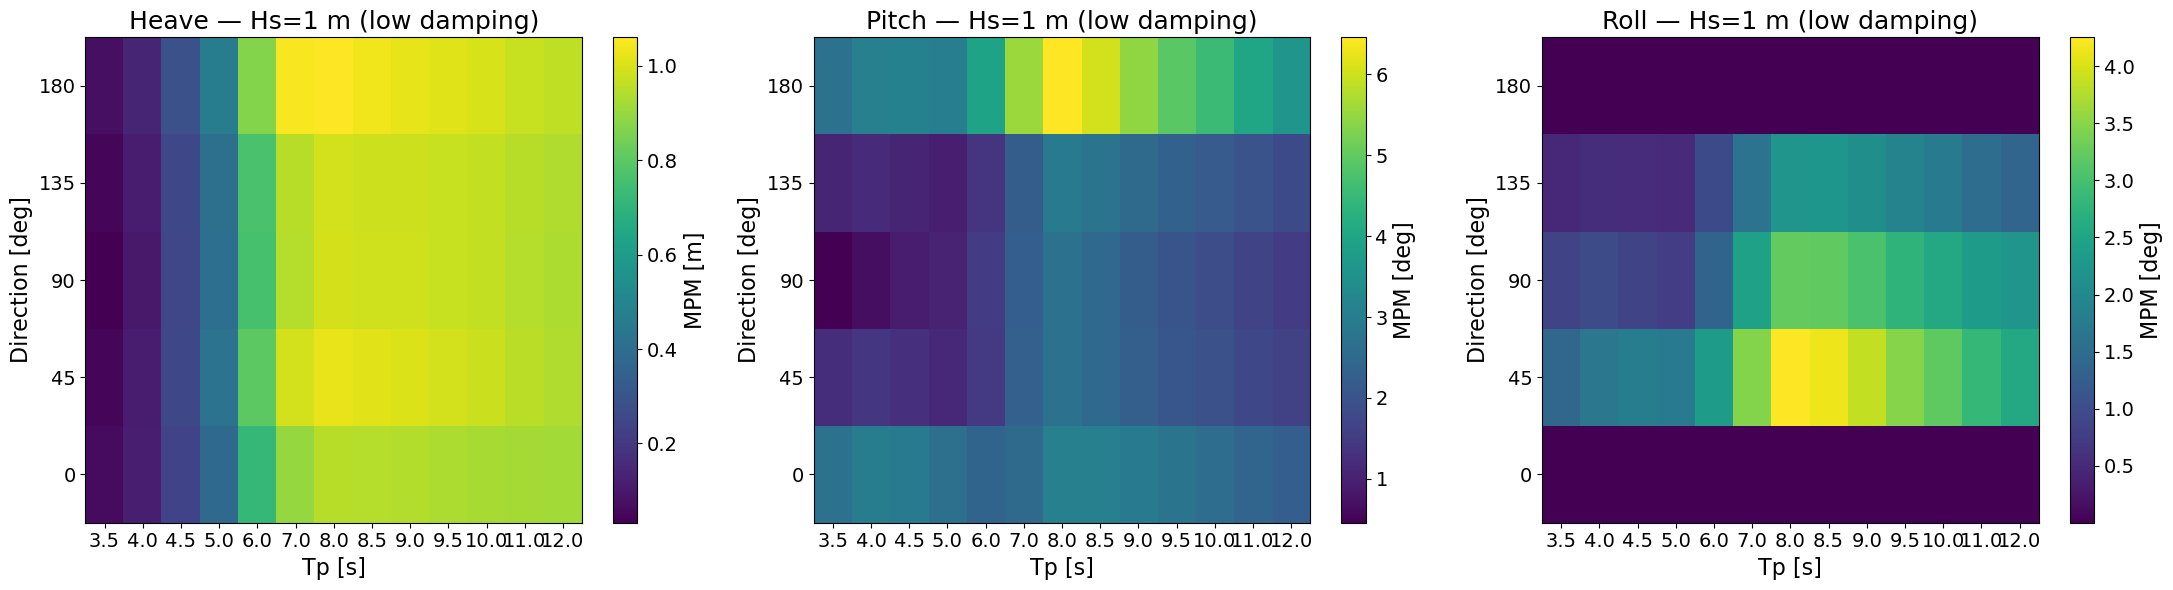

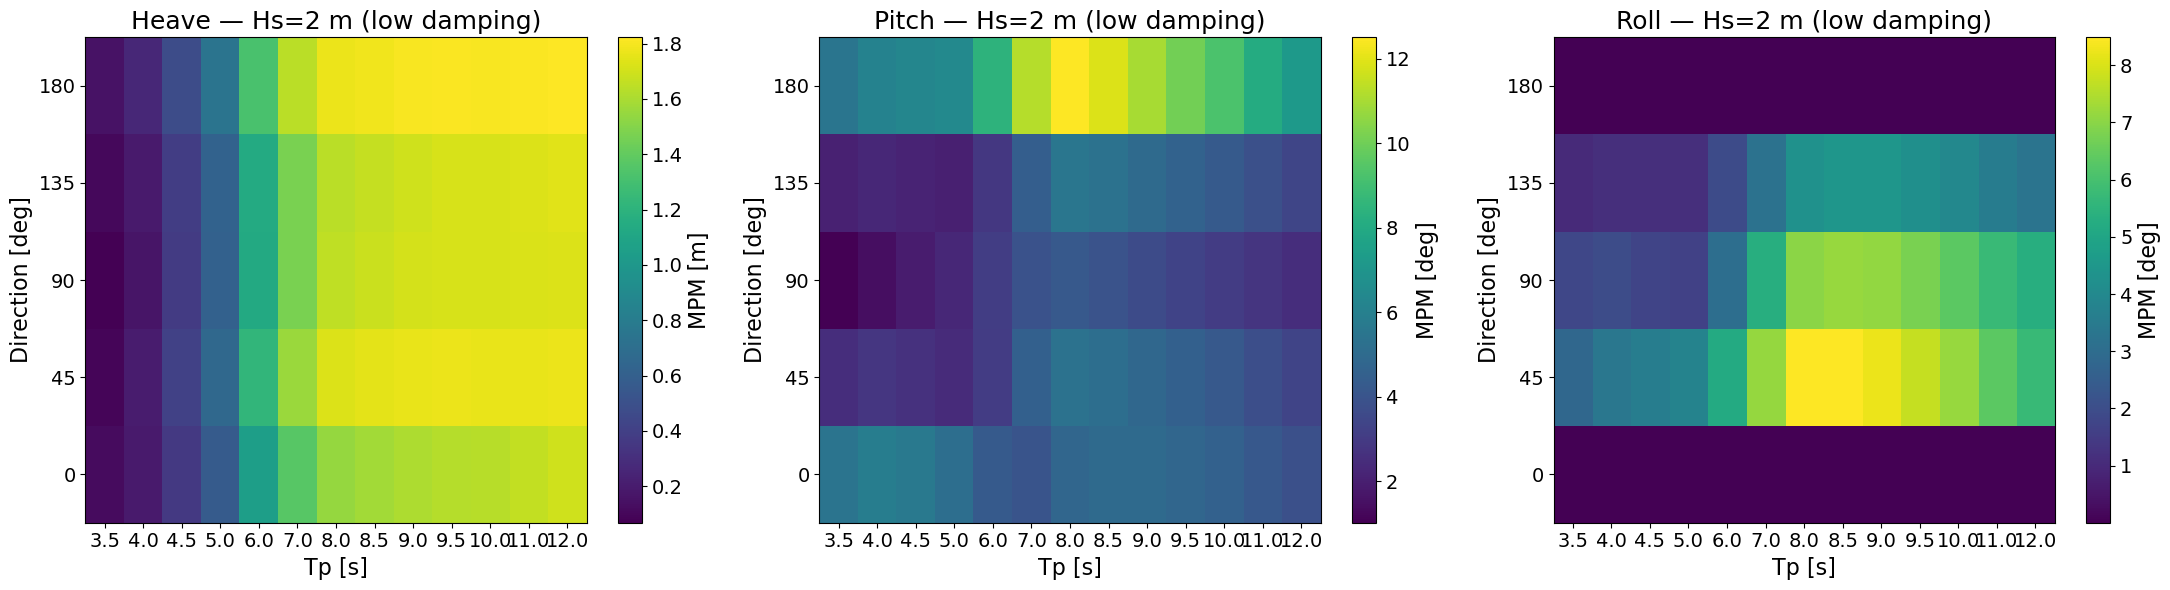

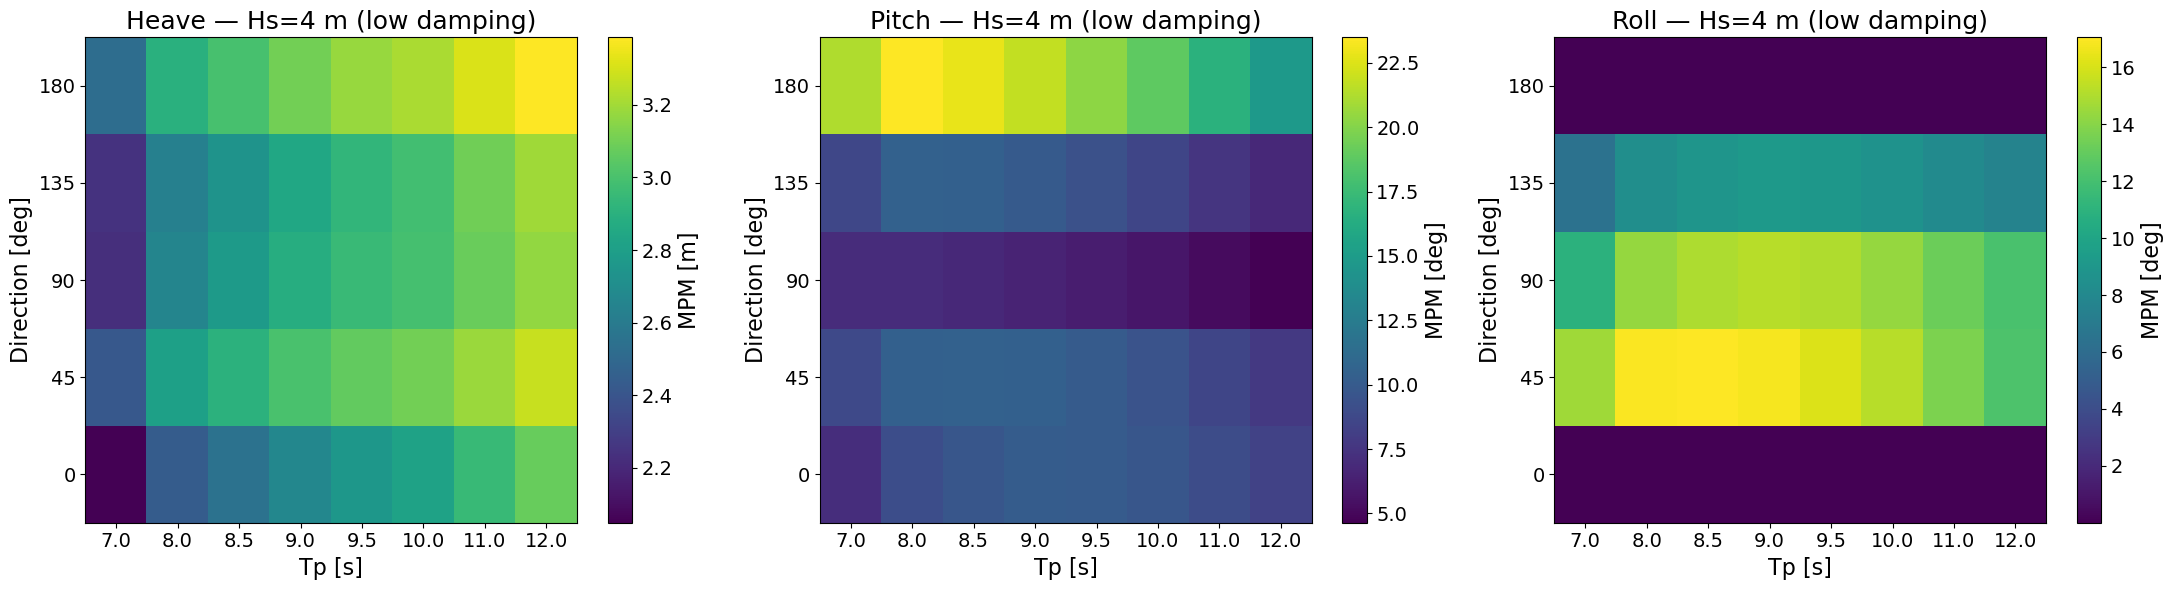

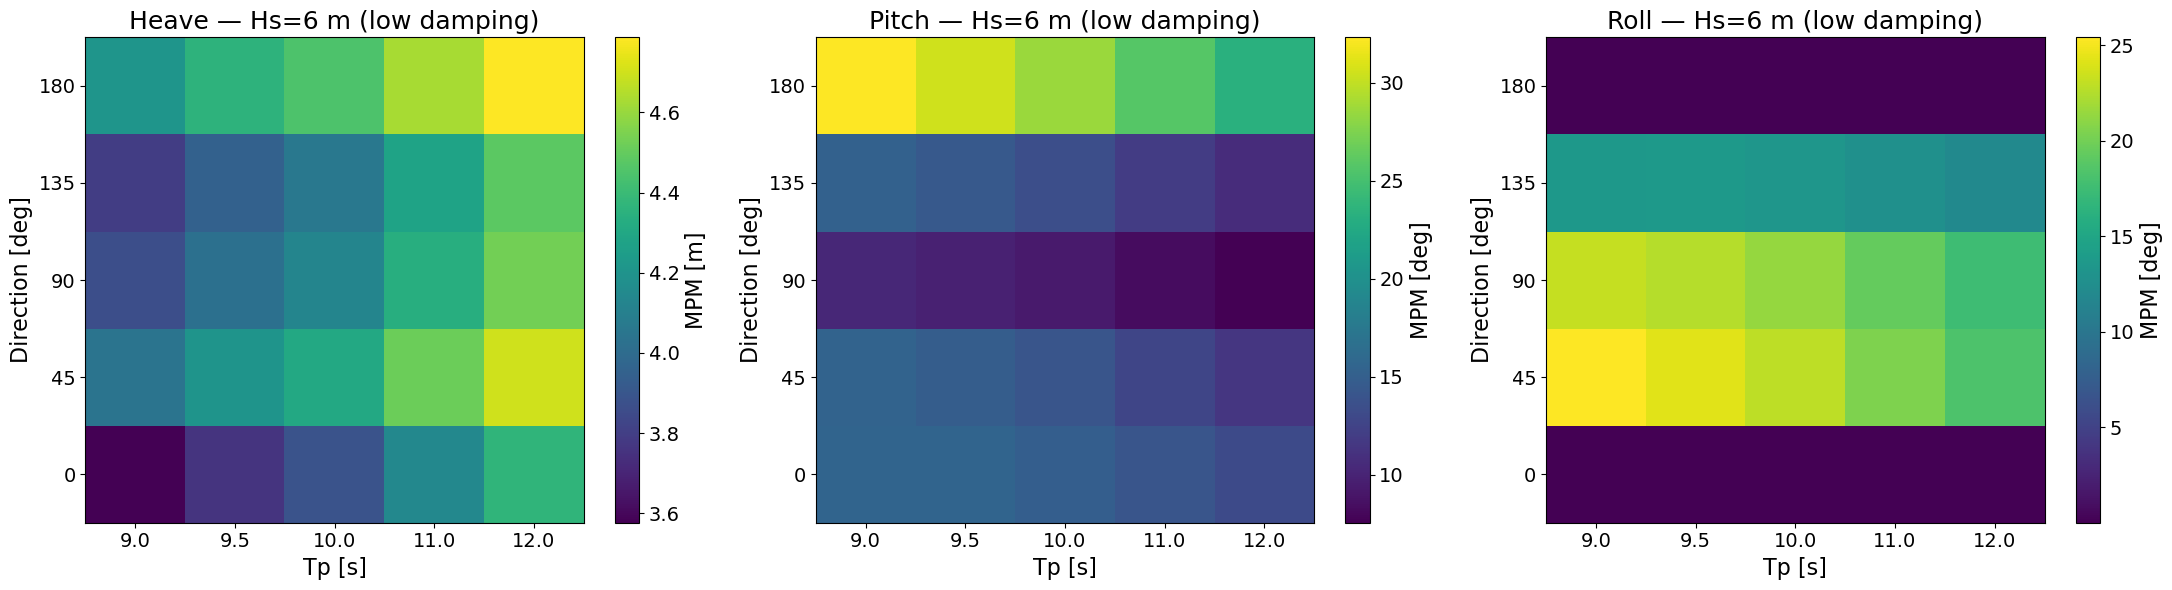

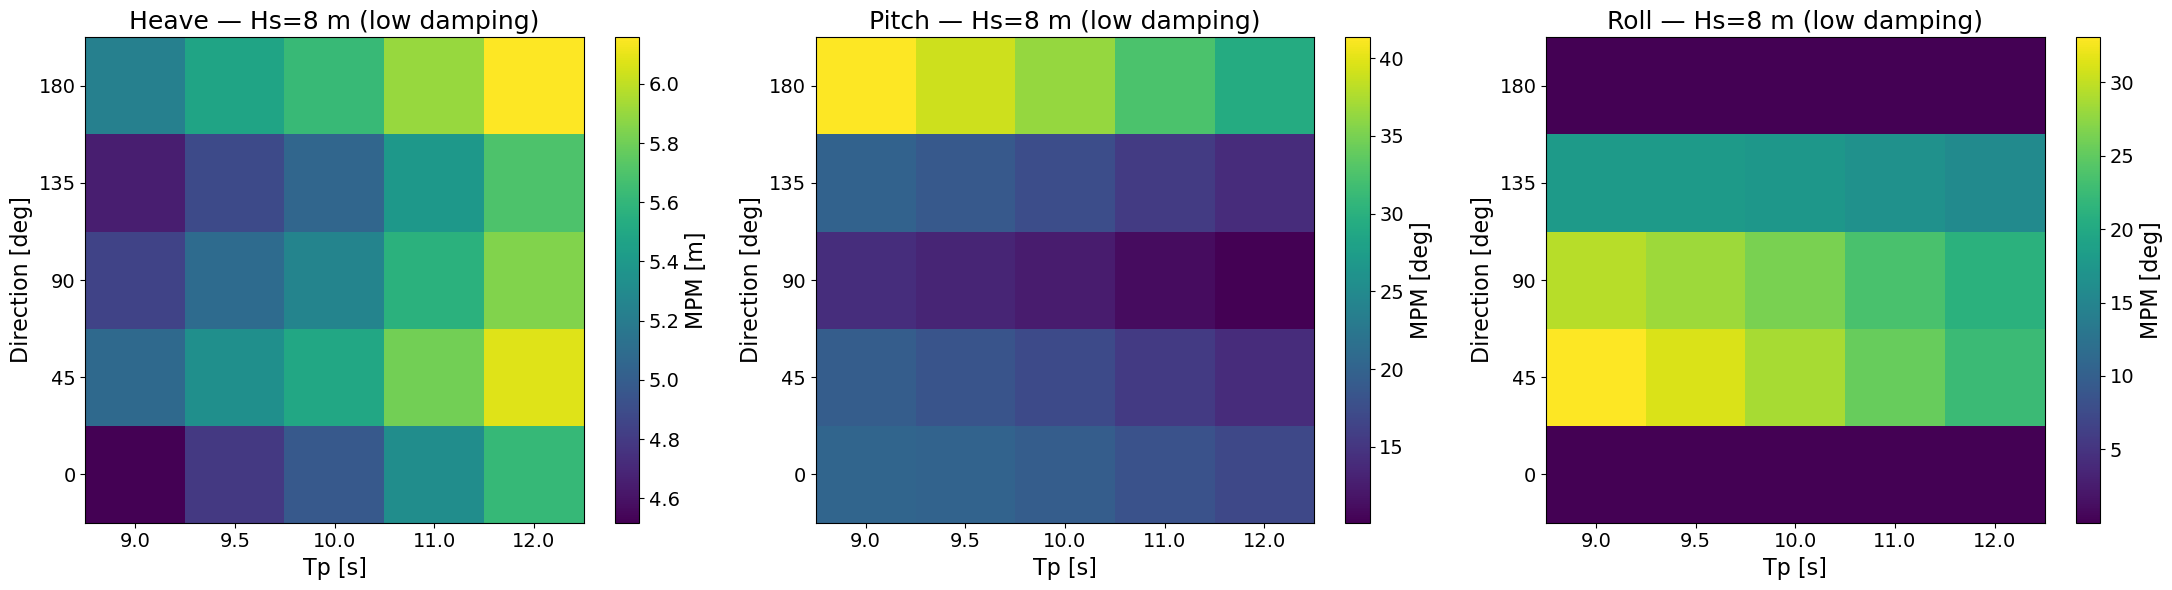

In [9]:
# MPM heatmap
for hs in HS_VALUES:
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sub_hs = df[(df['Hs'] == hs) & (df['Damp_Heave'] == 'low')]
    for ax, dof in zip(axes, DOFS):
        sub_dof = filter_dirs(sub_hs, dof)
        mpm_c = f'MPM {dof["key"]} corr'
        pivot = sub_dof.pivot_table(index='Direction', columns='Tp', values=mpm_c, aggfunc='mean')
        im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap='viridis')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel('Tp [s]')
        ax.set_ylabel('Direction [deg]')
        ax.set_title(f'{dof["name"]} — Hs={hs} m (low damping)')
        plt.colorbar(im, ax=ax, label=f'MPM [{dof["unit"]}]')
    fig.tight_layout()
plt.show()

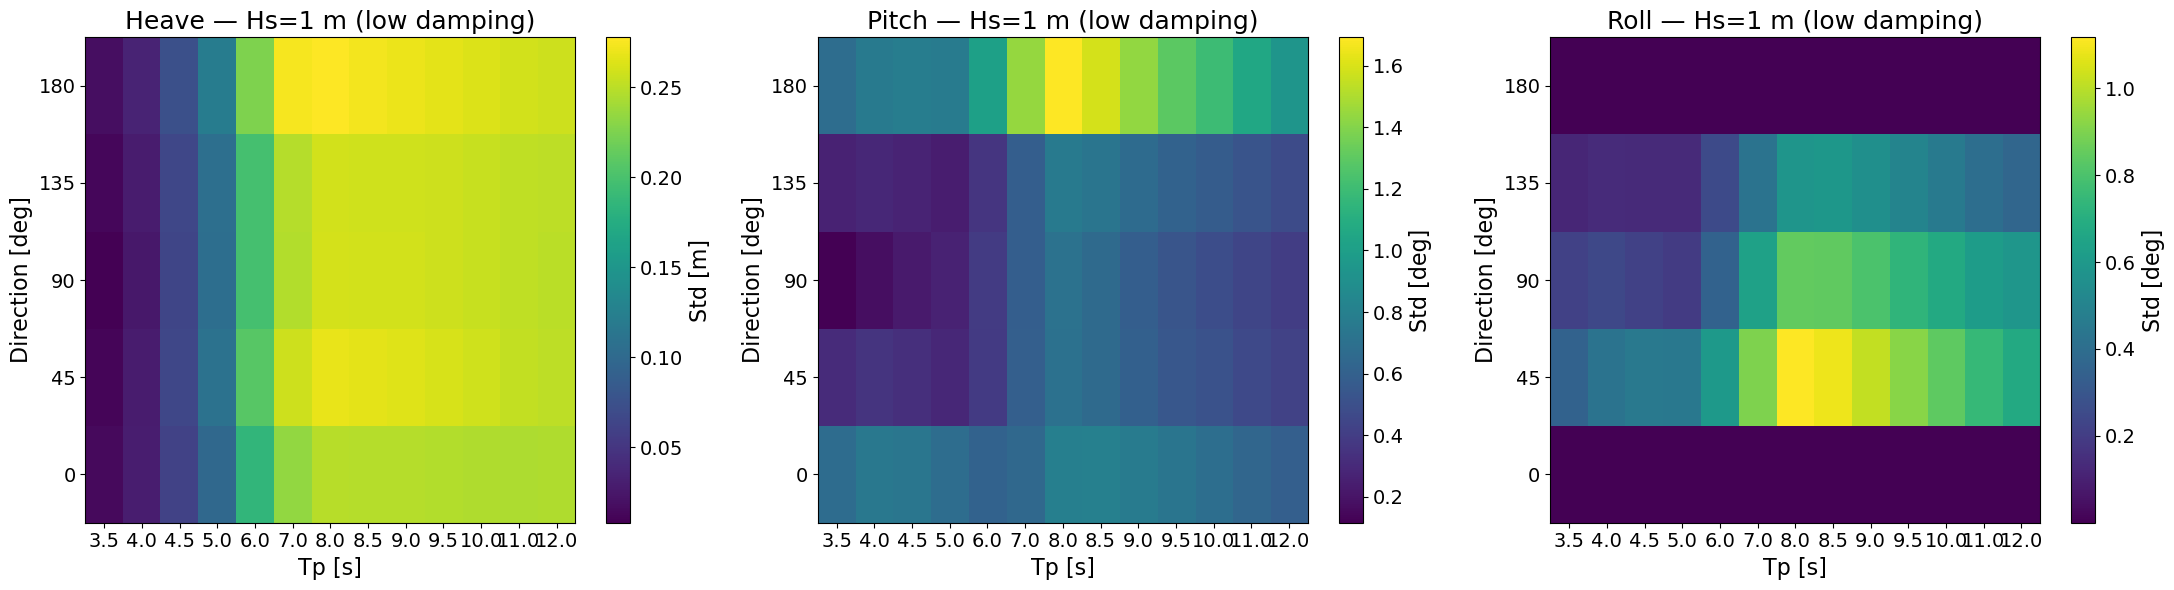

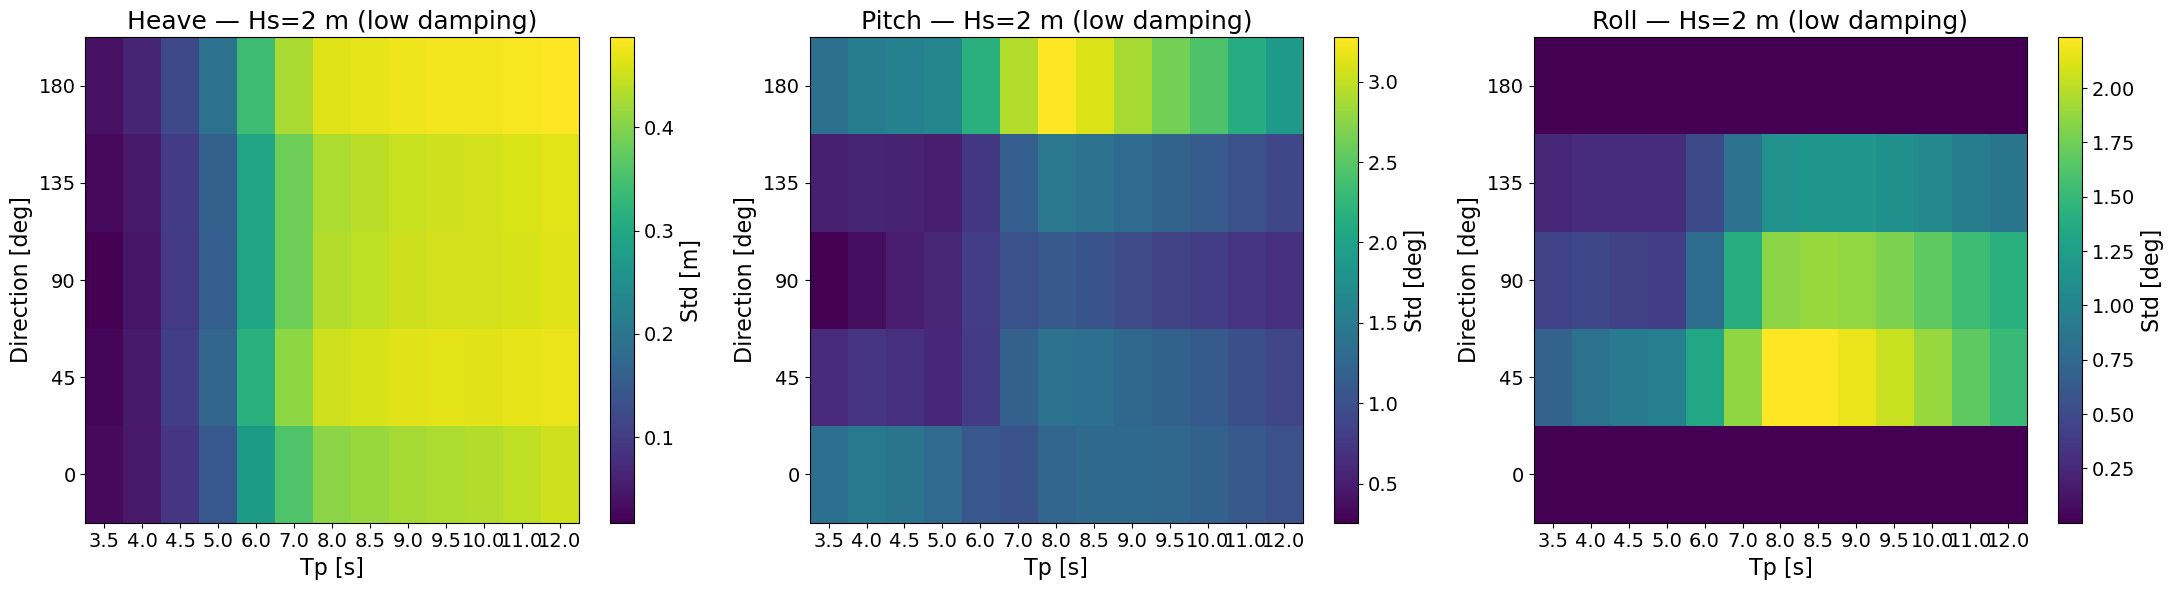

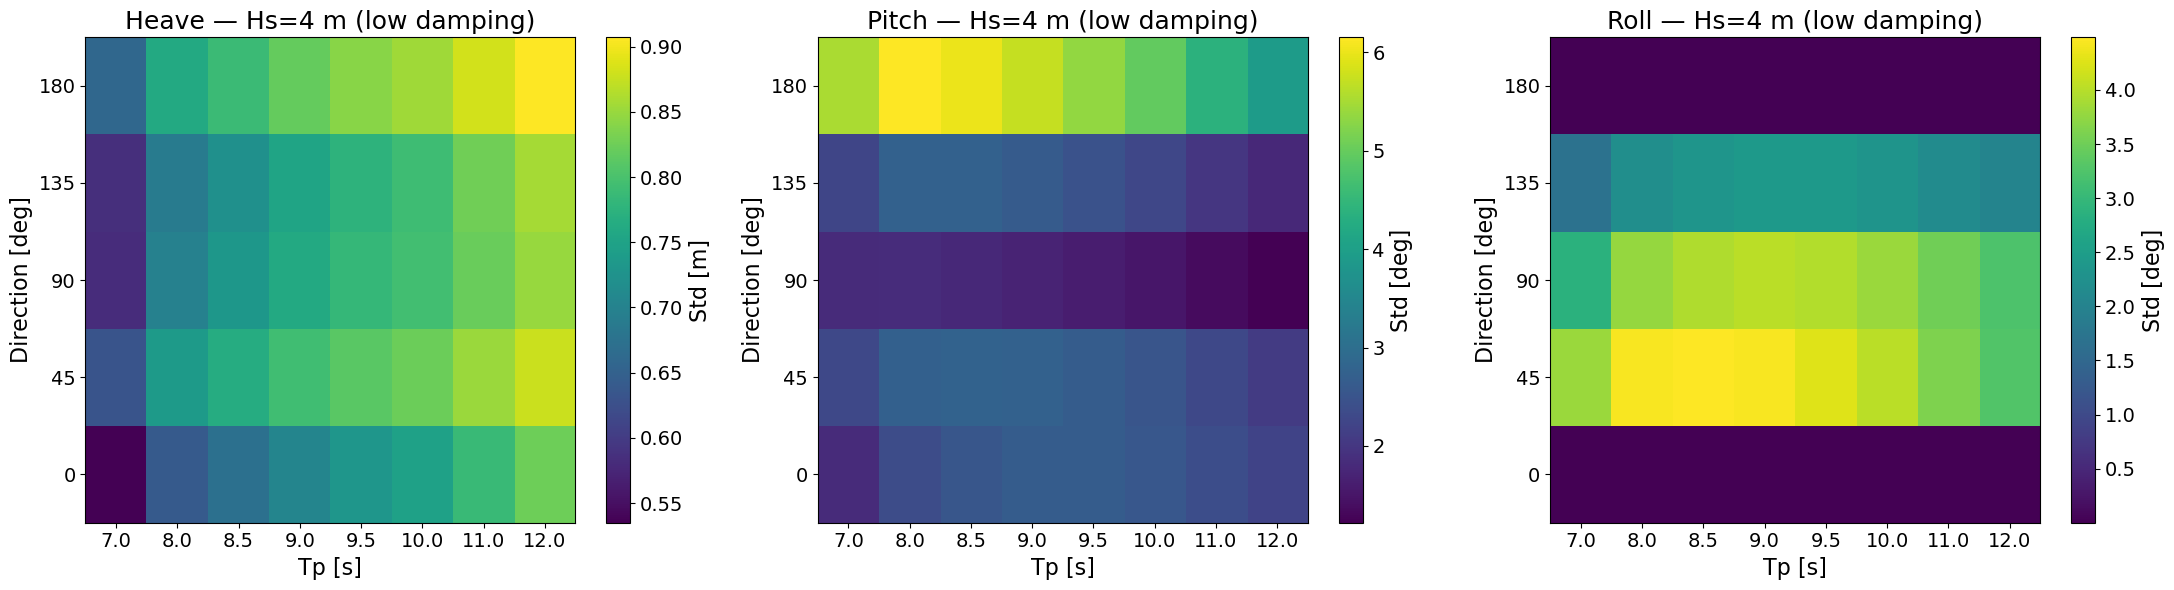

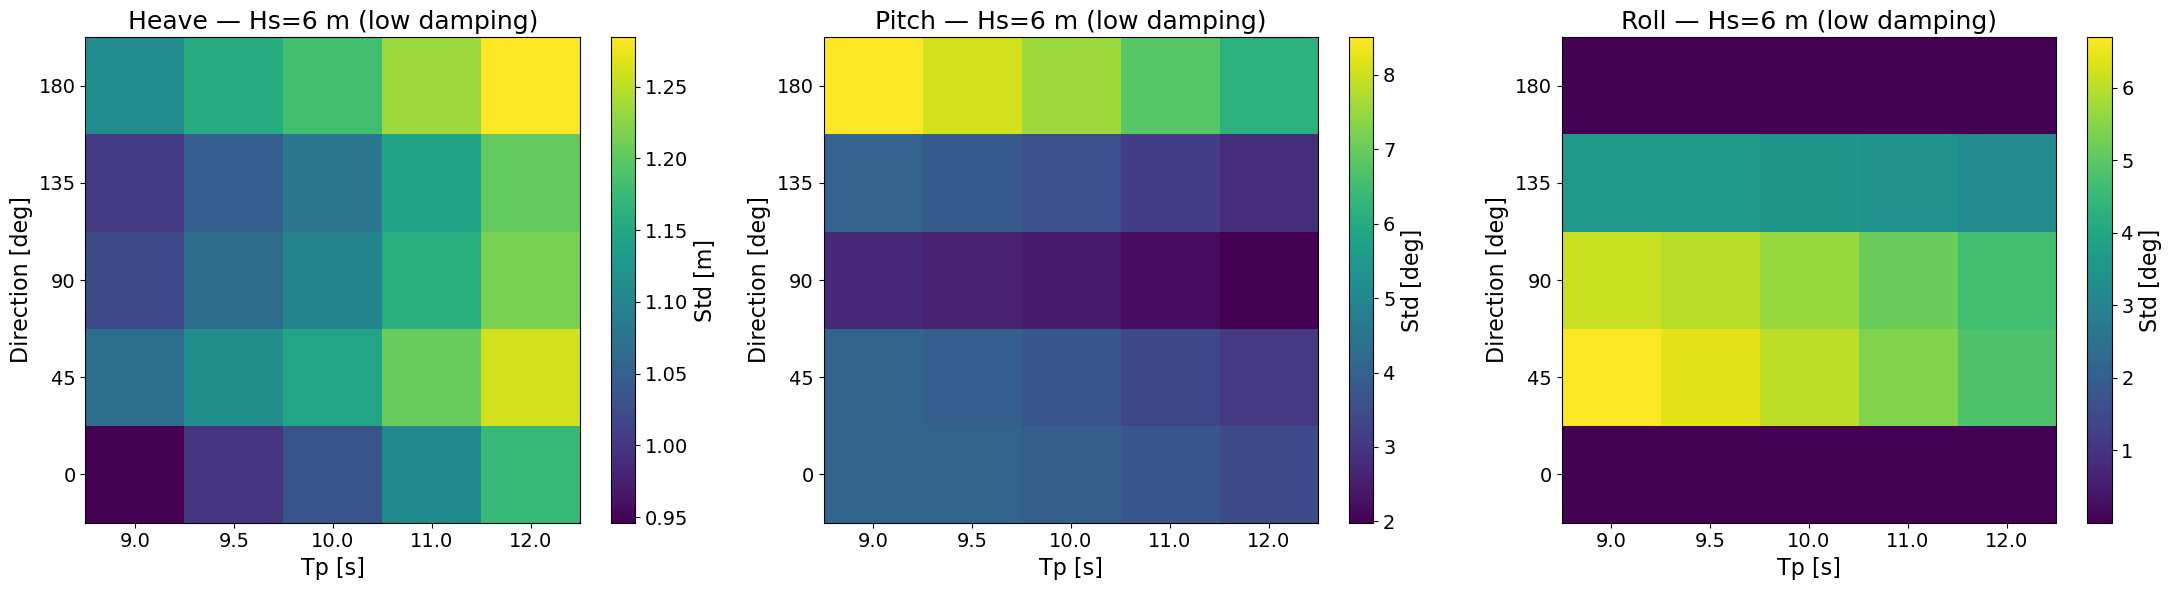

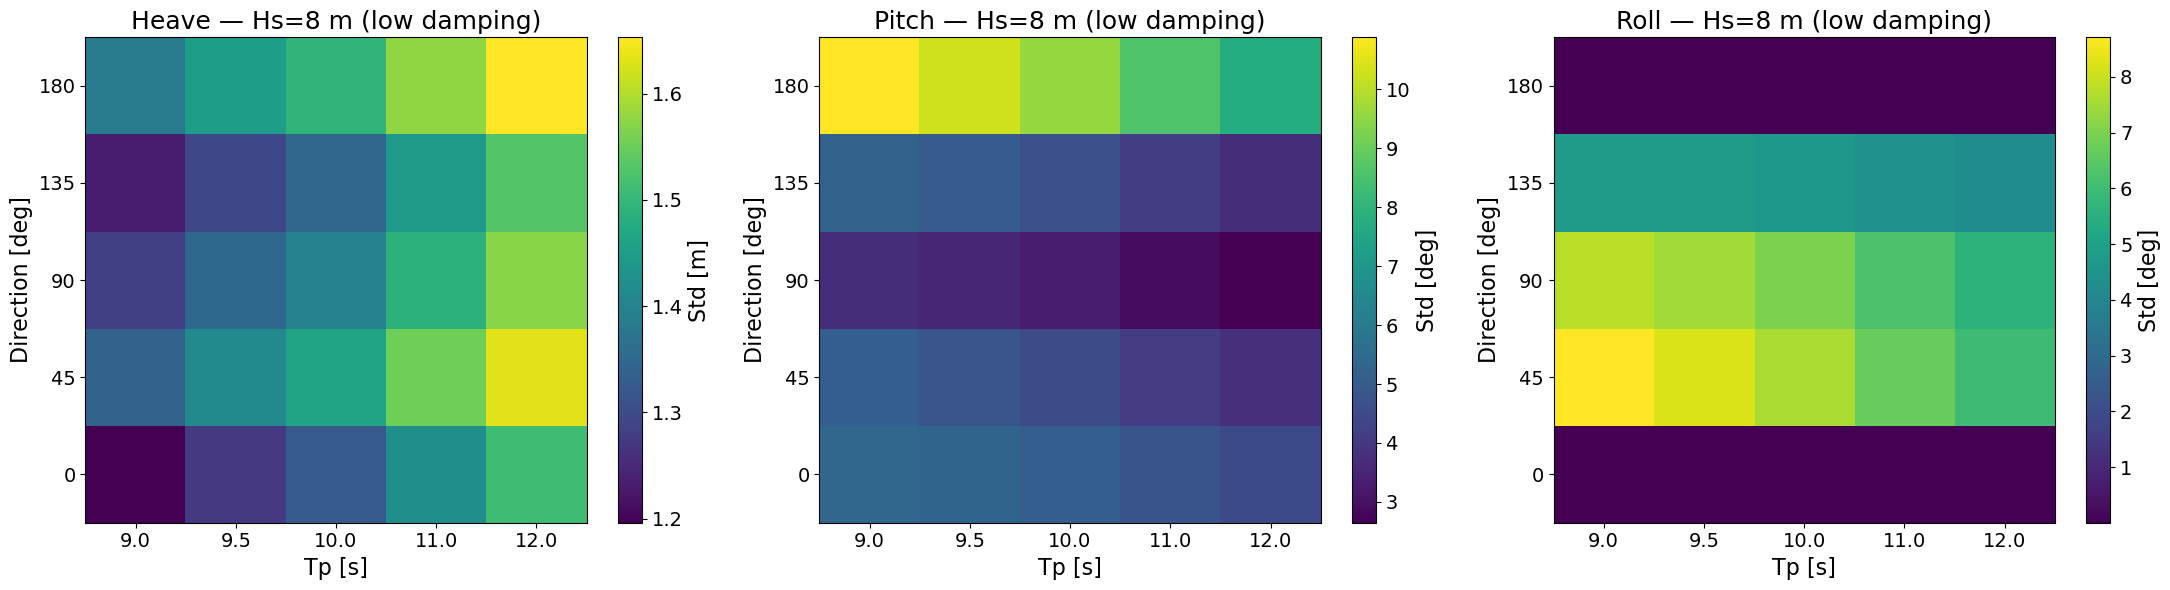

In [10]:
# Std heatmap
for hs in HS_VALUES:
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sub_hs = df[(df['Hs'] == hs) & (df['Damp_Heave'] == 'low')]
    for ax, dof in zip(axes, DOFS):
        sub_dof = filter_dirs(sub_hs, dof)
        std_c = std_col(dof['key'])
        pivot = sub_dof.pivot_table(index='Direction', columns='Tp', values=std_c, aggfunc='mean')
        im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap='viridis')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel('Tp [s]')
        ax.set_ylabel('Direction [deg]')
        ax.set_title(f'{dof["name"]} — Hs={hs} m (low damping)')
        plt.colorbar(im, ax=ax, label=f'Std [{dof["unit"]}]')
    fig.tight_layout()
plt.show()

## 7. Worst case summary table per DOF and damping case

In [11]:
rows = []
for dof in DOFS:
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'
    for case in DAMPING_CASES:
        sub_case = sub_dof[sub_dof[dcol] == case]
        if sub_case.empty:
            continue
        idx = sub_case[mpm_c].idxmax()
        row = sub_case.loc[idx]
        rows.append({
            'DOF': dof['name'],
            'Damping': case,
            'Hs': row['Hs'],
            'Tp': row['Tp'],
            'Direction': row['Direction'],
            'MPM corrected': row[mpm_c],
            'Std': row[std_col(dof['key'])],
        })

summary = pd.DataFrame(rows)
summary

,DOF,Damping,Hs,Tp,Direction,MPM corrected,Std
0,Heave,low,8,12.0,180,6.156915,1.652974
1,Heave,linhigh,8,12.0,180,6.085775,1.634334
2,Heave,quadhigh,8,12.0,180,6.095552,1.636729
3,Heave,average,8,12.0,180,6.098216,1.637560
4,Pitch,low,8,9.0,180,41.335679,10.879773
5,Pitch,linhigh,8,9.0,180,40.037789,10.538162
6,Pitch,quadhigh,8,9.0,180,39.583262,10.417469
7,Pitch,average,8,9.0,180,39.894155,10.499822
8,Roll,low,8,9.0,45,33.063800,8.709658
9,Roll,linhigh,8,9.0,45,31.813182,8.377636
